# **Model Evaluation**

**MSc thesis Euan Bronsky**

**Notebook number: 4**

This notebook focuses on the evaluation of the various estimated models. Namely, out-of-sample predictions are computed, which are evaluated by MSE and MAE, Diebold-Mariano tests, and Model Confidence Sets. Particular attention is drawn to the statistical significance of model differences.

- **Import dependencies**

In [1122]:
%reset -f
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.colors import TwoSlopeNorm
import statsmodels.api as sm
import pyfixest as pf

- **Load the data**

In [1123]:
# Import data
data = pd.read_parquet("/Users/euanbronsky/Downloads/data_final_final.parquet")

# Adjust the DataFrame
data = data.assign(
    forward_price = np.exp(data['r'] * data['T']) * data['underlying_last'],
    M = lambda x: np.log(x['strike'] / x['forward_price']) / np.sqrt(x['T']),
    log_iv=np.log(data['iv_fun']),
    moneyness_squared=lambda x: x['M'] **2,
    interaction= lambda x: x['T'] * x['M'],
    constant=1
).sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

# Locate the correct indices
data_select = data.loc[data.groupby(['quote_date', 'moneyness_group', 'maturity_group'])['distance'].idxmin()]

# Maintain only groups with length 24 and sort the dates
data_select = data_select.groupby('quote_date').filter(lambda x: len(x) == 24)

- **Import model results**

In [1124]:
# Basic model
with open("/Users/euanbronsky/PyCharmMiscProject/1first_results.pkl", "rb") as f:
    static_results = pickle.load(f)

# VAR model
with open("/Users/euanbronsky/PyCharmMiscProject/2model1_results.pkl", 'rb') as f:
    var_results = pickle.load(f)

# OU model
with open('/Users/euanbronsky/PyCharmMiscProject/3model_ou_results.pkl', 'rb') as f:
    ou_results = pickle.load(f)

# Spline model
with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    spline_results = pickle.load(f)

# **0. Functions**

-------------------------

First, several functions are created. Functions included are heatmap functions, group preparing functions, IV prediction functions, and MSE/MAE functions where several regions of the implied voltility surface are distinguished.

- **Heatmap functions**

In [1125]:
def make_residual_heatmap(data_heatmap, title='Average absolute residuals per group using full contract data', ax=None, show=True):

    # Ensure fixed moneyness and maturity orders
    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    # Copy the heatmap data
    data_heatmap = data_heatmap.copy()

    # Convert maturity column into an ordered categorical variable
    data_heatmap['maturity_group'] = pd.Categorical(
        data_heatmap['maturity_group'],
        categories=maturity_order,
        ordered=True)

    # Convert moneyness column into an ordered categorical variable
    data_heatmap['moneyness_group'] = pd.Categorical(
        data_heatmap['moneyness_group'],
        categories=moneyness_order,
        ordered=True)

    # Compute the table for the heatmap
    heatmap_table = data_heatmap.pivot_table(
        values='abs_residual',
        index='maturity_group',
        columns='moneyness_group',
        aggfunc='mean',
        observed=False
    ).reindex(index=maturity_order, columns=moneyness_order)

    # Create a new figure if no axis is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    # Draw the actual heatmap
    im = ax.imshow(heatmap_table, aspect='auto', cmap='Blues')

    # Write the actual numbers inside each heatmap cell
    for i in range(heatmap_table.shape[0]):
        for j in range(heatmap_table.shape[1]):
            ax.text(
                j, i, f"{heatmap_table.iloc[i, j]:.4f}",
                ha="center", va="center")

    # Set several specifics
    ax.invert_yaxis()
    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha='right')
    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)
    ax.set_xlabel('Moneyness group')
    ax.set_ylabel('Maturity group')
    ax.set_title(title)

    # Set the colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Average absolute residual')

    # Only finalize the layout and display the plot if show = True
    if show:
        fig.tight_layout()
        plt.show()

    # Return the table
    return heatmap_table

In [1126]:
# Residual heatmap function for state space models
def make_state_model_residual_heatmap(data_source, model_dates, state_array, prepare_groups_function, title='Average absolute residuals per group using full contract data', ax=None, show=True):

    # Only select rows whose quote date is used by the model
    data_heatmap = data_source[data_source['quote_date'].isin(model_dates)].copy()

    # Create ordered categorical variable
    data_heatmap['quote_date'] = pd.Categorical(
        data_heatmap['quote_date'],
        categories=model_dates,
        ordered=True)

    # Sort values
    data_heatmap = data_heatmap.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).copy()

    # Prepare groups and compute predictions
    dates_data, _, Z_groups_data = prepare_groups_function(data_heatmap)
    log_iv_pred, iv_pred = predict_iv(Z_groups_data, state_array[:, :len(dates_data)])

    # Store variables
    data_heatmap['log_iv_pred'] = log_iv_pred
    data_heatmap['iv_pred'] = iv_pred
    data_heatmap['residual'] = data_heatmap['iv_fun'] - data_heatmap['iv_pred']
    data_heatmap['abs_residual'] = np.abs(data_heatmap['residual'])

    # Create heatmap table
    heatmap_table = make_residual_heatmap(data_heatmap, title=title, ax=ax, show=show)

    # Return the results
    return data_heatmap, heatmap_table

- **Prepare groups**

In [1127]:
# Group preparing function
def prepare_groups(x):

    # Sort the data
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Extract dates and create empty lists
    dates = np.sort(x['quote_date'].unique())
    y_groups = []
    Z_groups = []

    # Loop over dates
    for date in dates:

        # Extract groups
        group = x[x['quote_date'] == date]

        # Extract relevant variables and append to lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']].to_numpy(dtype=float))

    # return the results
    return dates, y_groups, Z_groups

In [1128]:
# Group preparing function
def prepare_groups_spline(x):

    # Sort data
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Sort the dates
    dates = np.sort(x['quote_date'].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over the dates
    for date in dates:

        # Extract the groups
        group = x[x['quote_date'] == date]

        # Append the y and Z groups to the lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **Predict IV**

In [1129]:
# Prediction function
def predict_iv(Z_groups, at_pred):

    # Create empty list
    log_iv_pred = []

    # Loop over the number of groups
    for t in range(len(Z_groups)):

        # Extract the group
        Zt = Z_groups[t]

        # Extract the states
        beta_t = at_pred[:, t]

        # Compute predicted values
        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    # Concatenate results and compute IV
    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    # Return the results
    return log_iv_pred, iv_pred

In [1130]:
def predict_var_iv(x, beta_start, omega, Phi):

    # Sort the data
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).copy()

    # Initialize
    beta_prev = beta_start
    log_iv_pred = []
    iv_pred = []

    for date, group in x.groupby('quote_date'):

        # Forecast today's beta using yesterday's realized beta
        beta_forecast = omega + Phi @ beta_prev

        X = group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']]
        y = group['log_iv']

        log_pred = X @ beta_forecast

        log_iv_pred.append(pd.Series(log_pred, index=group.index, name='log_iv_pred'))
        iv_pred.append(pd.Series(np.exp(log_pred), index=group.index, name='iv_pred'))

        # After observing today's surface, estimate today's realized beta
        beta_prev = sm.OLS(y, X).fit().params.values

    return pd.concat(iv_pred)

In [1131]:
# Prediction function for the full data for the basic static model
def predict_var_iv_full(x_eval, x_bucketed, beta_start, omega, Phi):

    # Sort the values
    x_eval = x_eval.sort_values(
        ["quote_date", "moneyness_group", "maturity_group"]).copy()
    x_bucketed = x_bucketed.sort_values(
        ["quote_date", "moneyness_group", "maturity_group"]).copy()

    # Initialize
    beta_prev = beta_start
    iv_pred = []

    # Loop over the dates
    for date, group_eval in x_eval.groupby("quote_date"):

        # Compute forecast
        beta_forecast = omega + Phi @ beta_prev

        # Obtain regressor matric and prediction
        X_eval = group_eval[["constant", "M", "moneyness_squared", "T", "interaction"]]
        log_pred = X_eval @ beta_forecast

        # Append results to list
        iv_pred.append(pd.Series(np.exp(log_pred), index=group_eval.index, name="iv_pred"))

        # Obtain the bucketed data for the given date
        group_bucket = x_bucketed[x_bucketed["quote_date"] == date]

        # Check whether bucketed data is available for that date
        if len(group_bucket) > 0:

            # Obtain regressors and dependent variable
            X_bucket = group_bucket[["constant", "M", "moneyness_squared", "T", "interaction"]]
            y_bucket = group_bucket["log_iv"]

            # Compute previous beta based on the bucketed data
            beta_prev = sm.OLS(y_bucket, X_bucket).fit().params.values

        # Else use previous forecast
        else:
            beta_prev = beta_forecast

    # Return the predictions
    return pd.concat(iv_pred).sort_index()

- **MSE and MAE**

In [1132]:
# MSE and MAE function
def mse_mae(x, iv_pred):

    # Sort values and align
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).copy()
    iv_pred = pd.Series(iv_pred, index=x.index, name='iv_pred')

    # Compute errors
    errors = x['iv_fun'] - iv_pred

    # Extract dates
    dates = pd.to_datetime(x['quote_date'])

    # Create masks
    covid_mask = dates.between('2020-01-01', '2022-12-31')
    non_2023_mask = dates.dt.year != 2023

    # Compute squared error and absolute error
    se = errors**2
    ae = np.abs(errors)

    # Full testing sample metrics
    mse_full = se.groupby(dates).mean().mean()
    mae_full = ae.groupby(dates).mean().mean()

    # COVID metrics
    mse_covid = se[covid_mask].groupby(dates[covid_mask]).mean().mean()
    mae_covid = ae[covid_mask].groupby(dates[covid_mask]).mean().mean()

    # Non-COVID metrics
    mse_non_covid = se[~covid_mask].groupby(dates[~covid_mask]).mean().mean()
    mae_non_covid = ae[~covid_mask].groupby(dates[~covid_mask]).mean().mean()

    # Non-2023 metrics
    mse_non_2023 = se[non_2023_mask].groupby(dates[non_2023_mask]).mean().mean()
    mae_non_2023 = ae[non_2023_mask].groupby(dates[non_2023_mask]).mean().mean()

    # Return the results
    return (mse_full, mae_full, mse_covid, mae_covid, mse_non_covid, mae_non_covid, mse_non_2023, mae_non_2023)

In [1133]:
# Region-specific MSE and MAE
def mse_mae_region(x_test, iv_pred, region_name, region_col="region"):

    # Sort values and construct a series to align index
    x_sorted = x_test.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).copy()
    iv_pred = pd.Series(iv_pred, index=x_sorted.index)

    # Create boolean mask
    mask = x_sorted[region_col] == region_name

    # Apply boolean mask
    x_region = x_sorted.loc[mask].copy()
    pred_region = iv_pred.loc[mask]

    # Return the result
    return mse_mae(x_region,pred_region)

# **1. GENERAL METRICS**

# **1.1 Basic model**

------------------

The basic model entails the five-factor model with a separately estimated VAR(1) model. Evaluation metrics include the MSE and MAE, regional MSE and MAE, and heatmaps.

- **Extract the results**

In [1134]:
# Unpack the dictionary
df_betas_train = static_results["df_betas"]
omega = static_results["omega"]
Phi = static_results["Phi"]
x_test = static_results["x_test"]
x_train = static_results['x_train']

- **MSE and MAE on bucketed data**

In [1135]:
# Prediction function
iv_pred_basic = predict_var_iv(x_test, df_betas_train.iloc[-1].values, omega, Phi)

# Apply MSE and MAE functions
mse_full_basic, mae_full_basic, mse_covid_basic, mae_covid_basic, mse_non_covid_basic, mae_non_covid_basic, _, _ = mse_mae(x_test, iv_pred_basic)

# DOTM put and call regions
dotm_put_stats = mse_mae_region(x_test,iv_pred_basic, "DOTM_put",region_col="moneyness_group")
dotm_call_stats = mse_mae_region(x_test, iv_pred_basic, "DOTM_call", region_col="moneyness_group")

# Print the bucketed results
print("All buckets")
print(f"Full MSE: {mse_full_basic:.6f}, MAE: {mae_full_basic:.6f}")
print(f"Non-COVID MSE: {mse_non_covid_basic:.6f}, MAE: {mae_non_covid_basic:.6f}")
print(f"COVID MSE: {mse_covid_basic:.6f}, MAE: {mae_covid_basic:.6f} \n")

# DOTM put
print("DOTM put")
print(f"Full MSE: {dotm_put_stats[0]:.6f}, Full MAE: {dotm_put_stats[1]:.6f}")
print(f"Non-COVID MSE: {dotm_put_stats[4]:.6f}, Non-COVID MAE: {dotm_put_stats[5]:.6f}")
print(f"COVID MSE: {dotm_put_stats[2]:.6f}, COVID MAE: {dotm_put_stats[3]:.6f} \n")

# DOTM call
print("DOTM call")
print(f"Full MSE: {dotm_call_stats[0]:.6f}, Full MAE: {dotm_call_stats[1]:.6f}")
print(f"Non-COVID MSE: {dotm_call_stats[4]:.6f}, Non-COVID MAE: {dotm_call_stats[5]:.6f}")
print(f"COVID MSE: {dotm_call_stats[2]:.6f}, COVID MAE: {dotm_call_stats[3]:.6f}")

All buckets
Full MSE: 0.000331, MAE: 0.010778
Non-COVID MSE: 0.000092, MAE: 0.007243
COVID MSE: 0.000465, MAE: 0.012764 

DOTM put
Full MSE: 0.000389, Full MAE: 0.011737
Non-COVID MSE: 0.000110, Non-COVID MAE: 0.008462
COVID MSE: 0.000546, COVID MAE: 0.013576 

DOTM call
Full MSE: 0.000263, Full MAE: 0.009119
Non-COVID MSE: 0.000065, Non-COVID MAE: 0.005896
COVID MSE: 0.000374, COVID MAE: 0.010930


- **MSE and MAE on full data**

In [1136]:
# Full test evaluation for first model
x_test_full_first = data[data["quote_date"].isin(x_test["quote_date"].unique())
].sort_values(["quote_date", 'moneyness_group', 'maturity_group']).copy()

# Obtain IV predictions based on full contract data
iv_pred_first_full = predict_var_iv_full(
    x_eval=x_test_full_first,
    x_bucketed=x_test,
    beta_start=df_betas_train.iloc[-1].values,
    omega=omega,
    Phi=Phi)

# Compute MSE and MAE
mse_full_first_full, mae_full_first_full, mse_covid_first_full, mae_covid_first_full, _, _, mse_non_2023_first_full, mae_non_2023_first_full = mse_mae(x_test_full_first, iv_pred_first_full)

# DOTM put and call regions
dotm_put_stats_full_first = mse_mae_region(x_test_full_first, iv_pred_first_full, "DOTM_put", region_col="moneyness_group")
dotm_call_stats_full_first = mse_mae_region(x_test_full_first,iv_pred_first_full, "DOTM_call", region_col="moneyness_group")

# Print the results
print("Full non-bucketed test data")
print(f"Full MSE: {mse_full_first_full:.6f}, MAE: {mae_full_first_full:.6f}")
print(f"COVID  MSE: {mse_covid_first_full:.6f}, MAE: {mae_covid_first_full:.6f}")
print(f"Excluding 2023 MSE: {mse_non_2023_first_full:.6f}, MAE: {mae_non_2023_first_full:.6f} \n")

# DOTM put
print("Full non-bucketed test data: DOTM put")
print(f"Full MSE: {dotm_put_stats_full_first[0]:.6f}, Full MAE: {dotm_put_stats_full_first[1]:.6f}")
print(f"COVID MSE: {dotm_put_stats_full_first[2]:.6f}, COVID MAE: {dotm_put_stats_full_first[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_put_stats_full_first[6]:.6f}, Excluding 2023 MAE: {dotm_put_stats_full_first[7]:.6f} \n")

# DOTM call
print("\nFull non-bucketed test data: DOTM call")
print(f"Full MSE: {dotm_call_stats_full_first[0]:.6f}, Full MAE: {dotm_call_stats_full_first[1]:.6f}")
print(f"COVID MSE: {dotm_call_stats_full_first[2]:.6f}, COVID MAE: {dotm_call_stats_full_first[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_call_stats_full_first[6]:.6f}, Excluding 2023 MAE: {dotm_call_stats_full_first[7]:.6f}")

Full non-bucketed test data
Full MSE: 685715.726808, MAE: 0.722373
COVID  MSE: 0.499092, MAE: 0.067027
Excluding 2023 MSE: 0.411999, MAE: 0.059866 

Full non-bucketed test data: DOTM put
Full MSE: 1469906.284082, Full MAE: 1.605096
COVID MSE: 1.295971, COVID MAE: 0.147968
Excluding 2023 MSE: 1.068236, Excluding 2023 MAE: 0.130400 


Full non-bucketed test data: DOTM call
Full MSE: 0.001618, Full MAE: 0.023988
COVID MSE: 0.002260, COVID MAE: 0.028749
Excluding 2023 MSE: 0.001934, Excluding 2023 MAE: 0.026357


- **Heatmap**

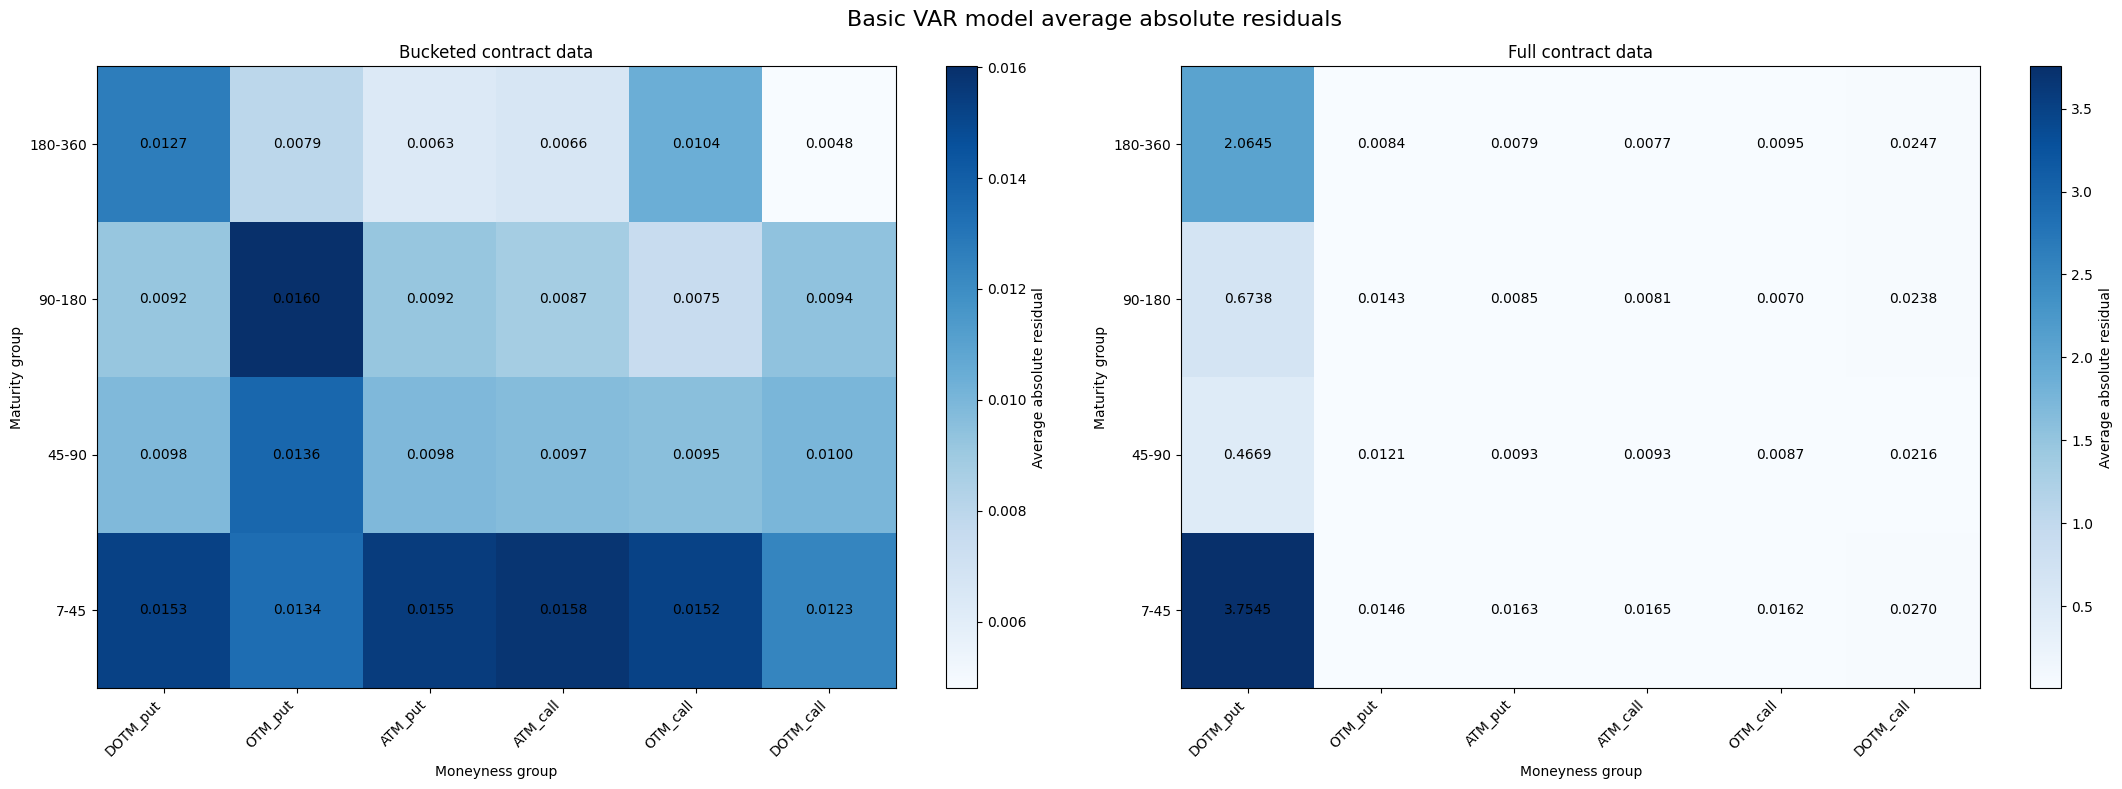

In [1137]:
# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Bucketed heatmap specifics
data_basic_bucketed = x_test.copy()
data_basic_bucketed["iv_pred"] = iv_pred_basic
data_basic_bucketed["abs_residual"] = np.abs(data_basic_bucketed["iv_fun"] - data_basic_bucketed["iv_pred"])

# Draw the bucketed heatmap
heatmap_table_basic_bucketed = make_residual_heatmap(
    data_basic_bucketed,
    title="Bucketed contract data",
    ax=axes[0],
    show=False)

# Full-data heatmap specifics
data_basic_full = x_test_full_first.copy()
data_basic_full["iv_pred"] = iv_pred_first_full
data_basic_full["abs_residual"] = np.abs(
    data_basic_full["iv_fun"] - data_basic_full["iv_pred"])

# Draw the full-data heatmap
heatmap_table_basic_full = make_residual_heatmap(
    data_basic_full,
    title="Full contract data",
    ax=axes[1],
    show=False)

# Plot the results
fig.suptitle("Basic VAR model average absolute residuals", fontsize=16)
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.basic2.png", bbox_inches='tight')
plt.show()

# **1.2 Five factor + VAR(1) model (state-space)**

--------------------------

The five-factor + VAR(1) model entails the one-step estimation state-space framework. Evaluaiton matrics include MSE and MAE, regional MSE and MAE, and heatmaps based on bucketed and full-contract data.

- **MSE and MAE**

In [1138]:
# Unpack relevant variables
at_pred_var = var_results["at_pred"]
x_train_var = var_results["x_train"]
x_test_var = var_results["x_test"]

# Prepare groups
dates_train_var, y_groups_train_var, Z_groups_train_var = prepare_groups(x_train_var)
n_train_dates_var = len(dates_train_var)

In [1139]:
# Bucketed test evaluation
dates_test_var, y_groups_test_var, Z_groups_test_var = prepare_groups(x_test_var)

# Predictions
log_iv_pred_test_var, iv_pred_test_var = predict_iv(Z_groups_test_var, at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_var)])

# MSE MAE
mse_full_var, mae_full_var, mse_covid_var, mae_covid_var, mse_non_covid_var, mae_non_covid_var, _, _ = mse_mae(x_test_var,iv_pred_test_var)

# DOTM put and call
dotm_put_stats_var = mse_mae_region(x_test_var, iv_pred_test_var, "DOTM_put",region_col="moneyness_group")
dotm_call_stats_var = mse_mae_region(x_test_var, iv_pred_test_var, "DOTM_call", region_col="moneyness_group")

# Bucketed data
print("Bucketed test data")
print(f"Full sample metrics, MSE: {mse_full_var:.6f}, MAE: {mae_full_var:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_var:.6f}, MAE: {mae_non_covid_var:.6f}")
print(f"COVID metrics, MSE: {mse_covid_var:.6f}, MAE: {mae_covid_var:.6f}\n")

# DOTM put
print("DOTM put")
print(f"Full MSE: {dotm_put_stats_var[0]:.6f}, Full MAE: {dotm_put_stats_var[1]:.6f}")
print(f"Non-COVID MSE: {dotm_put_stats_var[4]:.6f}, Non-COVID MAE: {dotm_put_stats_var[5]:.6f}")
print(f"COVID MSE: {dotm_put_stats_var[2]:.6f}, COVID MAE: {dotm_put_stats_var[3]:.6f} \n")

# DOTM call
print("DOTM call")
print(f"Full MSE: {dotm_call_stats_var[0]:.6f}, Full MAE: {dotm_call_stats_var[1]:.6f}")
print(f"Non-COVID MSE: {dotm_call_stats_var[4]:.6f}, Non-COVID MAE: {dotm_call_stats_var[5]:.6f}")
print(f"COVID MSE: {dotm_call_stats_var[2]:.6f}, COVID MAE: {dotm_call_stats_var[3]:.6f}")

Bucketed test data
Full sample metrics, MSE: 0.000367, MAE: 0.011261
Non-COVID metrics, MSE: 0.000101, MAE: 0.007554
COVID metrics, MSE: 0.000516, MAE: 0.013344

DOTM put
Full MSE: 0.000510, Full MAE: 0.013026
Non-COVID MSE: 0.000138, Non-COVID MAE: 0.009121
COVID MSE: 0.000719, COVID MAE: 0.015220 

DOTM call
Full MSE: 0.000358, Full MAE: 0.011295
Non-COVID MSE: 0.000096, Non-COVID MAE: 0.007603
COVID MSE: 0.000504, COVID MAE: 0.013370


In [1140]:
# Full test evaluation
x_test_full_var = data[data["quote_date"].isin(dates_test_var)].copy()
x_test_full_var = x_test_full_var.sort_values(["quote_date", 'moneyness_group', 'maturity_group']).copy()

# Obtain groups
dates_test_full_var, y_groups_test_full_var, Z_groups_test_full_var = prepare_groups(x_test_full_var)

# Make full contract data predictions
log_iv_pred_test_full_var, iv_pred_test_full_var = predict_iv(Z_groups_test_full_var, at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_full_var)])

# MSE and MAE on full data
mse_full_var_full, mae_full_var_full, mse_covid_var_full, mae_covid_var_full, _, _, mse_non_2023_var_full, mae_non_2023_var_full = mse_mae(x_test_full_var, iv_pred_test_full_var)

# DOTM put and call
dotm_put_stats_full_var = mse_mae_region(x_test_full_var,iv_pred_test_full_var,"DOTM_put",region_col="moneyness_group")
dotm_call_stats_full_var = mse_mae_region(x_test_full_var, iv_pred_test_full_var, "DOTM_call", region_col="moneyness_group")

# All buckets
print("Full test data")
print(f"Full sample metrics, MSE: {mse_full_var_full:.6f}, MAE: {mae_full_var_full:.6f}")
print(f"COVID metrics, MSE: {mse_covid_var_full:.6f}, MAE: {mae_covid_var_full:.6f}")
print(f"Excluding 2023 metrics, MSE: {mse_non_2023_var_full:.6f}, MAE: {mae_non_2023_var_full:.6f}\n")

# DOTM put
print("Full non-bucketed test data: DOTM put")
print(f"Full MSE: {dotm_put_stats_full_var[0]:.6f}, Full MAE: {dotm_put_stats_full_var[1]:.6f}")
print(f"COVID MSE: {dotm_put_stats_full_var[2]:.6f}, COVID MAE: {dotm_put_stats_full_var[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_put_stats_full_var[6]:.6f}, Excluding 2023 MAE: {dotm_put_stats_full_var[7]:.6f}\n")

# DOTM call
print("\nFull non-bucketed test data: DOTM call")
print(f"Full MSE: {dotm_call_stats_full_var[0]:.6f}, Full MAE: {dotm_call_stats_full_var[1]:.6f}")
print(f"COVID MSE: {dotm_call_stats_full_var[2]:.6f}, COVID MAE: {dotm_call_stats_full_var[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_call_stats_full_var[6]:.6f}, Excluding 2023 MAE: {dotm_call_stats_full_var[7]:.6f}")

Full test data
Full sample metrics, MSE: 0.277963, MAE: 0.042592
COVID metrics, MSE: 0.012565, MAE: 0.043321
Excluding 2023 metrics, MSE: 0.010604, MAE: 0.039214

Full non-bucketed test data: DOTM put
Full MSE: 0.651215, Full MAE: 0.085236
COVID MSE: 0.033484, COVID MAE: 0.084629
Excluding 2023 MSE: 0.028144, Excluding 2023 MAE: 0.075457


Full non-bucketed test data: DOTM call
Full MSE: 0.002167, Full MAE: 0.028477
COVID MSE: 0.003017, COVID MAE: 0.033915
Excluding 2023 MSE: 0.002572, Excluding 2023 MAE: 0.030903


- **Heatmaps**

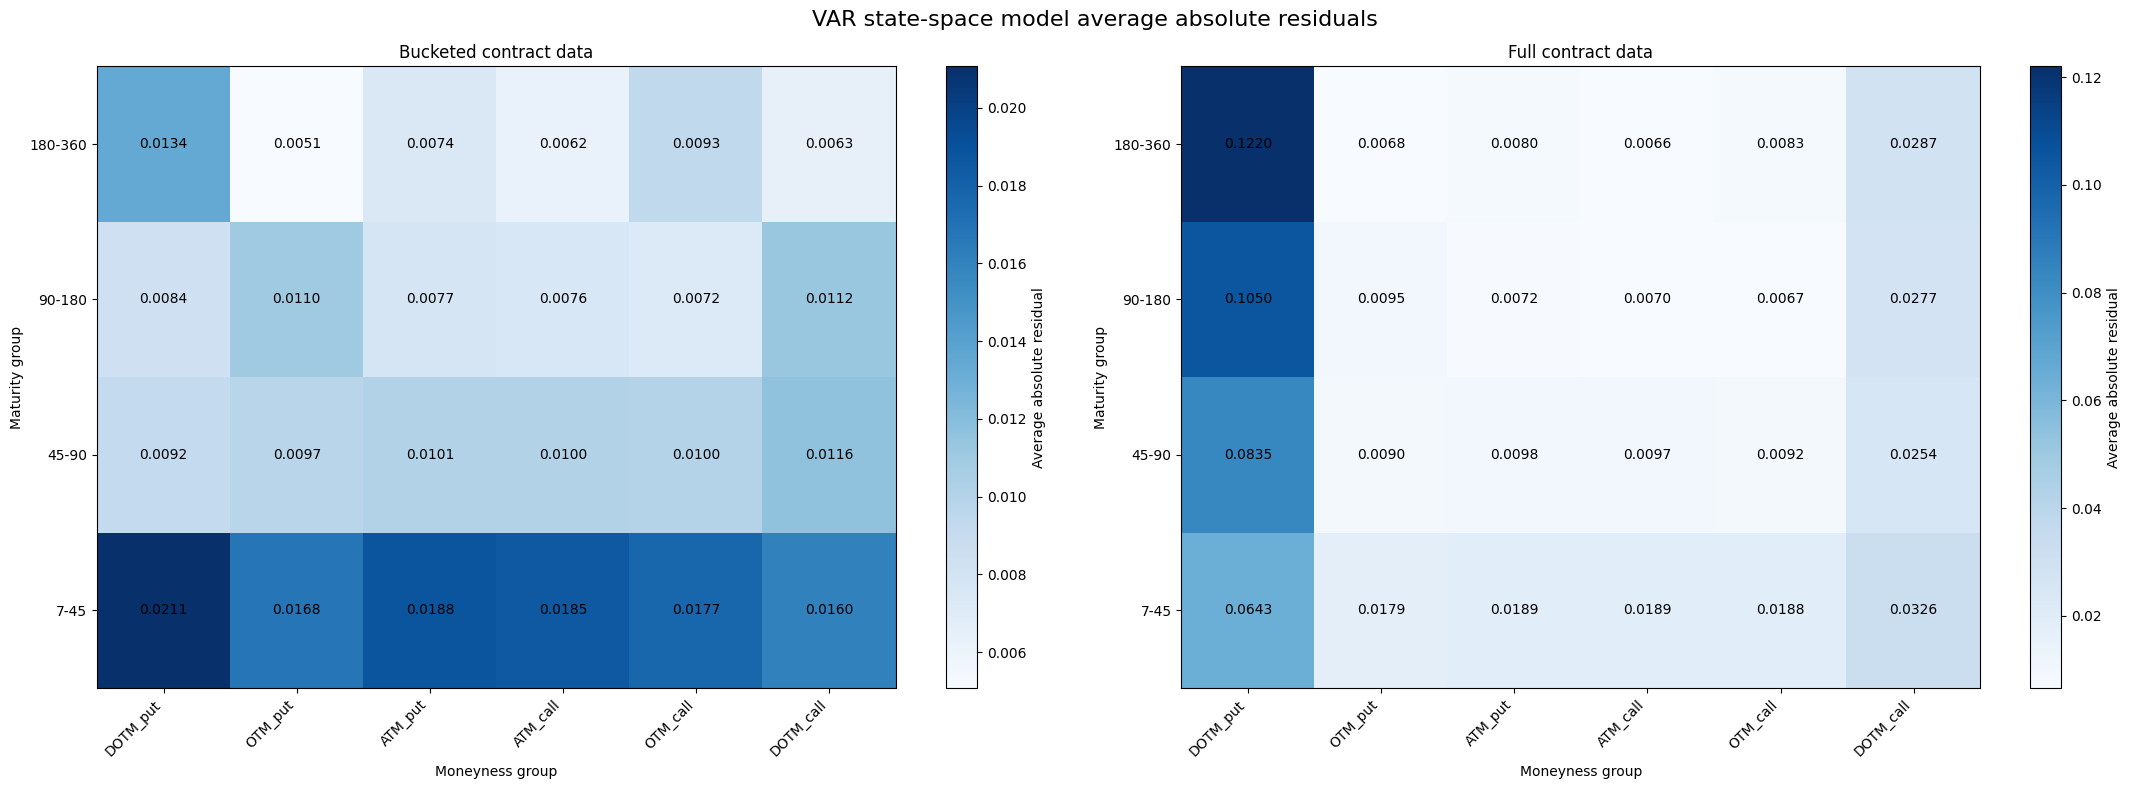

In [1141]:
# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Bucketed data heatmap
data_heatmap_var, heatmap_table_var = make_state_model_residual_heatmap(
    x_test,
    dates_test_var,
    at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_var)],
    prepare_groups,
    title="Bucketed contract data",
    ax=axes[0],
    show=False)

# Full contract data heatmap
data_heatmap_var_full, heatmap_table_var_full = make_state_model_residual_heatmap(
    x_test_full_var,
    dates_test_full_var,
    at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_full_var)],
    prepare_groups,
    title="Full contract data",
    ax=axes[1],
    show=False)

# Set common title
fig.suptitle(
    "VAR state-space model average absolute residuals",
    fontsize=16)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.VAR2.png", bbox_inches='tight')
plt.show()

In [1142]:
dates = np.sort(data_select["quote_date"].unique())
data_full_pred = data[data['quote_date'].isin(dates)].copy()

dates_full, _, Z_groups_full = prepare_groups(data_full_pred)

_, iv_pred_full = predict_iv(
    Z_groups_full,
    at_pred_var
)


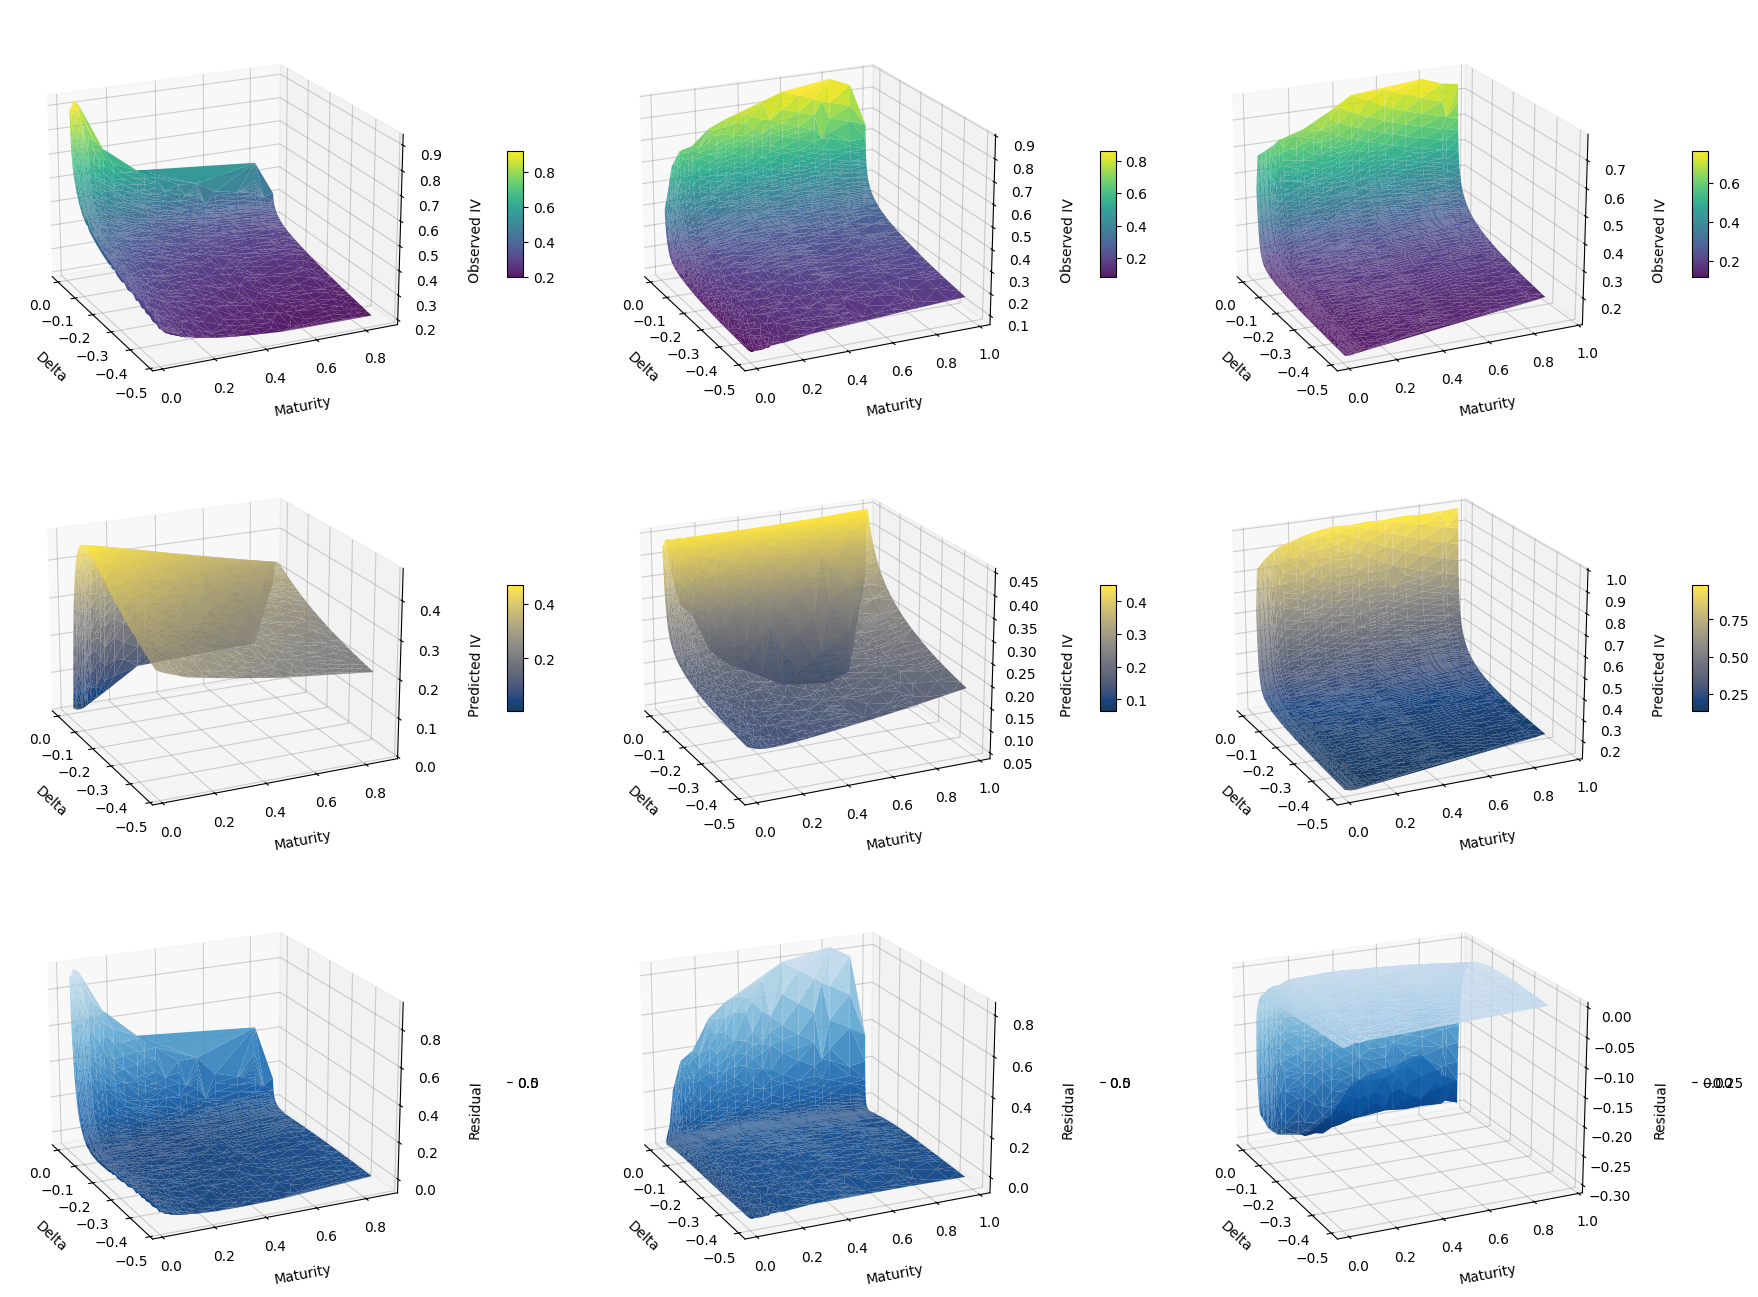

In [1143]:
blues_no_white = LinearSegmentedColormap.from_list(
    'blues_no_white',
    cm.Blues_r(np.linspace(0.02, 0.76, 256))
)

data_full_pred['iv_pred'] = iv_pred_full
data_full_pred['resid'] = data_full_pred['iv_fun'] - data_full_pred['iv_pred']

plot_dates = ['2020-03-04', '2021-06-25', '2023-08-07']

fig, axes = plt.subplots(
    3, 3,
    figsize=(18, 18),
    subplot_kw={'projection': '3d'}
)

for j, d in enumerate(plot_dates):
    date_df = data_full_pred.loc[
        (data_full_pred['quote_date'] == d) &
        (data_full_pred['option_type'] == 'put')
    ].copy()

    surf_obs = axes[0, j].plot_trisurf(
        date_df['delta_fun'],
        date_df['T'],
        date_df['iv_fun'],
        cmap='viridis',
        edgecolor='none',
        antialiased=True,
        alpha=0.9
    )

    surf_pred = axes[1, j].plot_trisurf(
        date_df['delta_fun'],
        date_df['T'],
        date_df['iv_pred'],
        cmap='cividis',
        edgecolor='none',
        antialiased=True,
        alpha=0.9
    )

    surf_resid = axes[2, j].plot_trisurf(
        date_df['delta_fun'],
        date_df['T'],
        date_df['resid'],
        cmap=blues_no_white,
        edgecolor='none',
        antialiased=True,
        alpha=0.9
    )

    fig.colorbar(surf_obs, ax=axes[0, j], shrink=0.14, aspect=8, pad=0.15)
    fig.colorbar(surf_pred, ax=axes[1, j], shrink=0.14, aspect=8, pad=0.15)
    fig.colorbar(surf_resid, ax=axes[2, j], shrink=0., aspect=8, pad=0.15)

for j in range(3):
    axes[0, j].set_xlabel('Delta', labelpad=10)
    axes[0, j].set_ylabel('Maturity', labelpad=10)
    axes[0, j].set_zlabel('Observed IV', labelpad=10)

    axes[1, j].set_xlabel('Delta', labelpad=10)
    axes[1, j].set_ylabel('Maturity', labelpad=10)
    axes[1, j].set_zlabel('Predicted IV', labelpad=10)

    axes[2, j].set_xlabel('Delta', labelpad=10)
    axes[2, j].set_ylabel('Maturity', labelpad=10)
    axes[2, j].set_zlabel('Residual', labelpad=10)

for ax in axes.flatten():

    ax.invert_xaxis()
    ax.view_init(elev=20, azim=-25)

    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.35)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.35)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.35)

fig.subplots_adjust(hspace=-0.60)
plt.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/predicted_and_residual_surfaces2.png", bbox_inches='tight')
plt.show()

In [1144]:


data_full_pred["abs_resid"] = data_full_pred["resid"].abs()

data_full_pred["deep_put"] = (
    data_full_pred["moneyness_group"] == "DOTM_put"
).astype(int)

data_full_pred["deep_call"] = (
    data_full_pred["moneyness_group"] == "DOTM_call"
).astype(int)

test_data = data_full_pred[
    data_full_pred["moneyness_group"].isin([
        "ATM_put", "ATM_call",
        "OTM_put", "OTM_call",
        "DOTM_put", "DOTM_call"
    ])
].copy()

reg = pf.feols(
    "abs_resid ~ deep_put + deep_call | quote_date + maturity_group",
    data=test_data,
    vcov={"CRV1": "quote_date"}
)

print(reg.summary())

gamma_put = reg.coef()["deep_put"]
se_put = reg.se()["deep_put"]
t_put = gamma_put / se_put
p_put = 1 - norm.cdf(t_put)

gamma_call = reg.coef()["deep_call"]
se_call = reg.se()["deep_call"]
t_call = gamma_call / se_call
p_call = 1 - norm.cdf(t_call)

print("gamma_put:", gamma_put)
print("t_put:", t_put)
print("one-sided p_put:", p_put)

print("gamma_call:", gamma_call)
print("t_call:", t_call)
print("one-sided p_call:", p_call)

###

Estimation:  OLS
Dep. var.: abs_resid, Fixed effects: quote_date + maturity_group
sample: None = all
Inference:  CRV1
Observations:  5681503

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| deep_put      |      0.056 |        0.002 |    25.312 |      0.000 |  0.051 |   0.060 |
| deep_call     |      0.013 |        0.000 |    34.039 |      0.000 |  0.012 |   0.014 |
---
RMSE: 0.441 R2: 0.01 R2 Within: 0.003 
None
gamma_put: 0.05571444684444784
t_put: 25.31232817727907
one-sided p_put: 0.0
gamma_call: 0.012779804586423757
t_call: 34.03942888512338
one-sided p_call: 0.0


# **1.3 OU model**

--------------------------

The OU model entails the five-factor model with Ornstein-Uhlenbeck dynamics estimated in a state-space framework. Metrics include the MSE and MAE, regional MSE and MAE, bucketed heatmaps, and non-bucketed heatmaps.

In [1145]:
# Extract the factor predictions
at_pred_ou = ou_results["at_pred"]

# Prepare groups
dates_train_ou, y_groups_train_ou, Z_groups_train_ou = prepare_groups(x_train)

# Extract number of dates
n_train_dates_ou = len(dates_train_ou)

In [1146]:
# Bucketed test evaluation
dates_test_ou, y_groups_test_ou, Z_groups_test_ou = prepare_groups(x_test)

# Predictions
log_iv_pred_test_ou, iv_pred_test_ou = predict_iv(
    Z_groups_test_ou,at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_ou)])

# MSE MAE
mse_full_ou, mae_full_ou, mse_covid_ou, mae_covid_ou, mse_non_covid_ou, mae_non_covid_ou, _, _ = mse_mae(x_test,iv_pred_test_ou)

# DOTM put and call, bucketed
dotm_put_stats_ou = mse_mae_region(x_test,iv_pred_test_ou,"DOTM_put",region_col="moneyness_group")
dotm_call_stats_ou = mse_mae_region(x_test,iv_pred_test_ou,"DOTM_call",region_col="moneyness_group")

# Print bucketed results
print("Bucketed test data")
print(f"Full sample metrics, MSE: {mse_full_ou:.6f}, MAE: {mae_full_ou:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_ou:.6f}, MAE: {mae_non_covid_ou:.6f}")
print(f"COVID metrics, MSE: {mse_covid_ou:.6f}, MAE: {mae_covid_ou:.6f}\n")

# DOTM put
print("DOTM put")
print(f"Full MSE: {dotm_put_stats_ou[0]:.6f}, Full MAE: {dotm_put_stats_ou[1]:.6f}")
print(f"Non-COVID MSE: {dotm_put_stats_ou[4]:.6f}, Non-COVID MAE: {dotm_put_stats_ou[5]:.6f}")
print(f"COVID MSE: {dotm_put_stats_ou[2]:.6f}, COVID MAE: {dotm_put_stats_ou[3]:.6f}\n")

# DOTM call
print("DOTM call")
print(f"Full MSE: {dotm_call_stats_ou[0]:.6f}, Full MAE: {dotm_call_stats_ou[1]:.6f}")
print(f"Non-COVID MSE: {dotm_call_stats_ou[4]:.6f}, Non-COVID MAE: {dotm_call_stats_ou[5]:.6f}")
print(f"COVID MSE: {dotm_call_stats_ou[2]:.6f}, COVID MAE: {dotm_call_stats_ou[3]:.6f}")

Bucketed test data
Full sample metrics, MSE: 0.000388, MAE: 0.011450
Non-COVID metrics, MSE: 0.000104, MAE: 0.007633
COVID metrics, MSE: 0.000548, MAE: 0.013594

DOTM put
Full MSE: 0.000531, Full MAE: 0.012290
Non-COVID MSE: 0.000123, Non-COVID MAE: 0.008045
COVID MSE: 0.000760, COVID MAE: 0.014674

DOTM call
Full MSE: 0.000443, Full MAE: 0.012911
Non-COVID MSE: 0.000131, Non-COVID MAE: 0.008997
COVID MSE: 0.000619, COVID MAE: 0.015109


In [1147]:
# Full non-bucketed test evaluation
x_test_full_ou = data[data["quote_date"].isin(dates_test_ou)].copy()
x_test_full_ou = x_test_full_ou.sort_values(["quote_date", 'moneyness_group', 'maturity_group']).copy()

# Prepare groups
dates_test_full_ou, y_groups_test_full_ou, Z_groups_test_full_ou = prepare_groups(x_test_full_ou)

# Predictions
log_iv_pred_test_full_ou, iv_pred_test_full_ou = predict_iv(Z_groups_test_full_ou,at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_full_ou)])

# MSE MAE
mse_full_ou_full, mae_full_ou_full, mse_covid_ou_full, mae_covid_ou_full, _, _, mse_non_2023_ou_full, mae_non_2023_ou_full = mse_mae(x_test_full_ou,iv_pred_test_full_ou)

# DOTM put and call
dotm_put_stats_full_ou = mse_mae_region(x_test_full_ou,iv_pred_test_full_ou,"DOTM_put",region_col="moneyness_group")
dotm_call_stats_full_ou = mse_mae_region(x_test_full_ou,iv_pred_test_full_ou,"DOTM_call",region_col="moneyness_group")

# Full data
print("Full test data")
print(f"Full sample metrics, MSE: {mse_full_ou_full:.6f}, MAE: {mae_full_ou_full:.6f}")
print(f"COVID metrics, MSE: {mse_covid_ou_full:.6f}, MAE: {mae_covid_ou_full:.6f}")
print(f"Excluding 2023 metrics, MSE: {mse_non_2023_ou_full:.6f}, MAE: {mae_non_2023_ou_full:.6f}\n")

# DOTM put
print("Full non-bucketed test data: DOTM put")
print(f"Full MSE: {dotm_put_stats_full_ou[0]:.6f}, Full MAE: {dotm_put_stats_full_ou[1]:.6f}")
print(f"COVID MSE: {dotm_put_stats_full_ou[2]:.6f}, COVID MAE: {dotm_put_stats_full_ou[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_put_stats_full_ou[6]:.6f}, Excluding 2023 MAE: {dotm_put_stats_full_ou[7]:.6f}\n")

# DOTM call
print("\nFull non-bucketed test data: DOTM call")
print(f"Full MSE: {dotm_call_stats_full_ou[0]:.6f}, Full MAE: {dotm_call_stats_full_ou[1]:.6f}")
print(f"COVID MSE: {dotm_call_stats_full_ou[2]:.6f}, COVID MAE: {dotm_call_stats_full_ou[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_call_stats_full_ou[6]:.6f}, Excluding 2023 MAE: {dotm_call_stats_full_ou[7]:.6f}")

Full test data
Full sample metrics, MSE: 0.010198, MAE: 0.039372
COVID metrics, MSE: 0.013457, MAE: 0.047190
Excluding 2023 metrics, MSE: 0.011425, MAE: 0.042778

Full non-bucketed test data: DOTM put
Full MSE: 0.026806, Full MAE: 0.077202
COVID MSE: 0.035546, COVID MAE: 0.093602
Excluding 2023 MSE: 0.030055, Excluding 2023 MAE: 0.083748


Full non-bucketed test data: DOTM call
Full MSE: 0.002450, Full MAE: 0.030998
COVID MSE: 0.003398, COVID MAE: 0.036700
Excluding 2023 MSE: 0.002892, Excluding 2023 MAE: 0.033379


- **Heatmap**

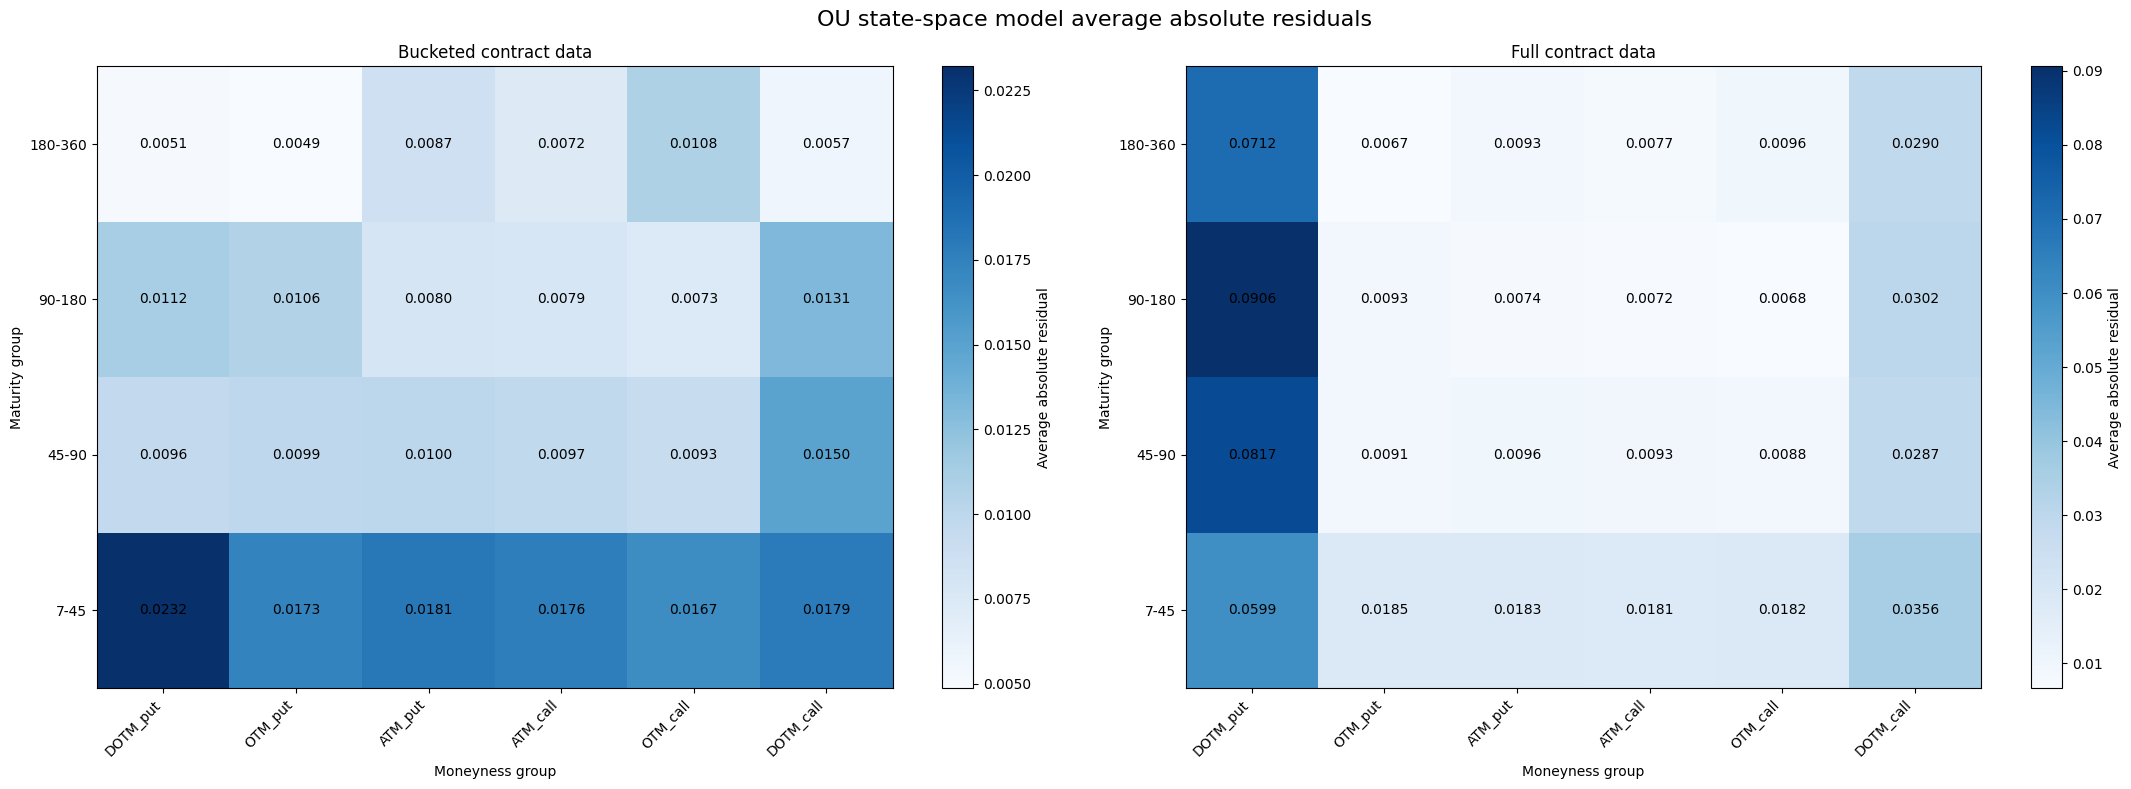

In [1148]:
# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Bucketed heatmap
data_heatmap_ou, heatmap_table_ou = make_state_model_residual_heatmap(
    x_test,
    dates_test_ou,
    at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_ou)],
    prepare_groups,
    title="Bucketed contract data",
    ax=axes[0],
    show=False)

# Full contract data heatmap
data_heatmap_ou_full, heatmap_table_ou_full = make_state_model_residual_heatmap(
    x_test_full_ou,
    dates_test_full_ou,
    at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_full_ou)],
    prepare_groups,
    title="Full contract data",
    ax=axes[1],
    show=False)

# Set a common title
fig.suptitle(
    "OU state-space model average absolute residuals",
    fontsize=16)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.OU2.png", bbox_inches='tight')
plt.show()

# **1.4 Spline model**

-----------------------------

The SPline model entails the spline basis construction with Ornstein-Uhlenbeck dynamics. Metrics include the MSE and MAE, the regional MSE and MAE, the bucketed heatmap, and the full contract data heatmap.

- **Extract variables, groups, and predictions**

In [ ]:
# Extract spline model variables
at_pred_spline = spline_results["at_pred"]
x_train_spline = spline_results["x_train_spline"]
x_test_spline = spline_results["x_test_spline"]
basis_cols = spline_results["basis_cols"]

# Obtain groups
dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(x_train_spline)
n_train_dates_spline = len(dates_train_spline)
dates_test_spline, y_groups_test_spline, Z_groups_test_spline = prepare_groups_spline(x_test_spline)

# Predictions
log_iv_pred_test_spline, iv_pred_test_spline = predict_iv(Z_groups_test_spline,at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_spline)])

- **Compute MSE and MAE**

In [1149]:
# MSE MAE full
mse_full_spline, mae_full_spline, mse_covid_spline, mae_covid_spline, mse_non_covid_spline, mae_non_covid_spline, _, _ = mse_mae(x_test_spline,iv_pred_test_spline)

# DOTM put and call
dotm_put_stats_spline = mse_mae_region(x_test_spline,iv_pred_test_spline,"DOTM_put",region_col="moneyness_group")
dotm_call_stats_spline = mse_mae_region(x_test_spline,iv_pred_test_spline,"DOTM_call",region_col="moneyness_group")

# Full data
print("Bucketed test data")
print(f"Full sample metrics, MSE: {mse_full_spline:.6f}, MAE: {mae_full_spline:.6f}")
print(f"Non-COVID metrics, MSE: {mse_non_covid_spline:.6f}, MAE: {mae_non_covid_spline:.6f}")
print(f"COVID metrics, MSE: {mse_covid_spline:.6f}, MAE: {mae_covid_spline:.6f}")

# DOTM put
print("DOTM put")
print(f"Full MSE: {dotm_put_stats_spline[0]:.6f}, Full MAE: {dotm_put_stats_spline[1]:.6f}")
print(f"Non-COVID MSE: {dotm_put_stats_spline[4]:.6f}, Non-COVID MAE: {dotm_put_stats_spline[5]:.6f}")
print(f"COVID MSE: {dotm_put_stats_spline[2]:.6f}, COVID MAE: {dotm_put_stats_spline[3]:.6f}")

# DOTM call
print("DOTM call")
print(f"Full MSE: {dotm_call_stats_spline[0]:.6f}, Full MAE: {dotm_call_stats_spline[1]:.6f}")
print(f"Non-COVID MSE: {dotm_call_stats_spline[4]:.6f}, Non-COVID MAE: {dotm_call_stats_spline[5]:.6f}")
print(f"COVID MSE: {dotm_call_stats_spline[2]:.6f}, COVID MAE: {dotm_call_stats_spline[3]:.6f}")

Bucketed test data
Full sample metrics, MSE: 0.000181, MAE: 0.008372
Non-COVID metrics, MSE: 0.000072, MAE: 0.005888
COVID metrics, MSE: 0.000244, MAE: 0.009792
DOTM put
Full MSE: 0.000312, Full MAE: 0.010392
Non-COVID MSE: 0.000098, Non-COVID MAE: 0.006610
COVID MSE: 0.000434, COVID MAE: 0.012555
DOTM call
Full MSE: 0.000113, Full MAE: 0.006558
Non-COVID MSE: 0.000047, Non-COVID MAE: 0.004783
COVID MSE: 0.000152, COVID MAE: 0.007574


In [1150]:
# Train predictions for spline model
log_iv_pred_train_spline, iv_pred_train_spline = predict_iv(
    Z_groups_train_spline,
    at_pred_spline[:, :n_train_dates_spline]
)

In [1151]:
# Full non-bucketed test evaluation
data_spline_full = spline_results["data_spline_full"]
x_test_full_spline = data_spline_full[data_spline_full["quote_date"].isin(dates_test_spline)].copy()
x_test_full_spline = x_test_full_spline.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()

# Prepare groups
dates_test_full_spline, y_groups_test_full_spline, Z_groups_test_full_spline = prepare_groups_spline(x_test_full_spline)

# Predictions
log_iv_pred_test_full_spline, iv_pred_test_full_spline = predict_iv(
    Z_groups_test_full_spline,at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline)])

# MSE MAE
mse_full_spline_full, mae_full_spline_full, mse_covid_spline_full, mae_covid_spline_full, _, _, mse_non_2023_spline_full, mae_non_2023_spline_full = mse_mae(x_test_full_spline,iv_pred_test_full_spline)

# DOTM put and call
dotm_put_stats_full_spline = mse_mae_region(x_test_full_spline,iv_pred_test_full_spline,"DOTM_put",region_col="moneyness_group")
dotm_call_stats_full_spline = mse_mae_region(x_test_full_spline,iv_pred_test_full_spline,"DOTM_call",region_col="moneyness_group")

# Full data
print("Full test data")
print(f"Full sample metrics, MSE: {mse_full_spline_full:.6f}, MAE: {mae_full_spline_full:.6f}")
print(f"COVID metrics, MSE: {mse_covid_spline_full:.6f}, MAE: {mae_covid_spline_full:.6f}")
print(f"Excluding 2023 metrics, MSE: {mse_non_2023_spline_full:.6f}, MAE: {mae_non_2023_spline_full:.6f}\n")

# DOTM put
print("Full non-bucketed test data: DOTM put")
print(f"Full MSE: {dotm_put_stats_full_spline[0]:.6f}, Full MAE: {dotm_put_stats_full_spline[1]:.6f}")
print(f"COVID MSE: {dotm_put_stats_full_spline[2]:.6f}, COVID MAE: {dotm_put_stats_full_spline[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_put_stats_full_spline[6]:.6f}, Excluding 2023 MAE: {dotm_put_stats_full_spline[7]:.6f}\n")

# DOTM call
print("\nFull non-bucketed test data: DOTM call")
print(f"Full MSE: {dotm_call_stats_full_spline[0]:.6f}, Full MAE: {dotm_call_stats_full_spline[1]:.6f}")
print(f"COVID MSE: {dotm_call_stats_full_spline[2]:.6f}, COVID MAE: {dotm_call_stats_full_spline[3]:.6f}")
print(f"Excluding 2023 MSE: {dotm_call_stats_full_spline[6]:.6f}, Excluding 2023 MAE: {dotm_call_stats_full_spline[7]:.6f}")

Full test data
Full sample metrics, MSE: 0.006772, MAE: 0.034849
COVID metrics, MSE: 0.006238, MAE: 0.033858
Excluding 2023 metrics, MSE: 0.006905, MAE: 0.036046

Full non-bucketed test data: DOTM put
Full MSE: 0.019474, Full MAE: 0.081387
COVID MSE: 0.018664, COVID MAE: 0.078712
Excluding 2023 MSE: 0.019859, Excluding 2023 MAE: 0.083254


Full non-bucketed test data: DOTM call
Full MSE: 0.000426, Full MAE: 0.014164
COVID MSE: 0.000543, COVID MAE: 0.016162
Excluding 2023 MSE: 0.000488, Excluding 2023 MAE: 0.015331


- **Heatmaps**

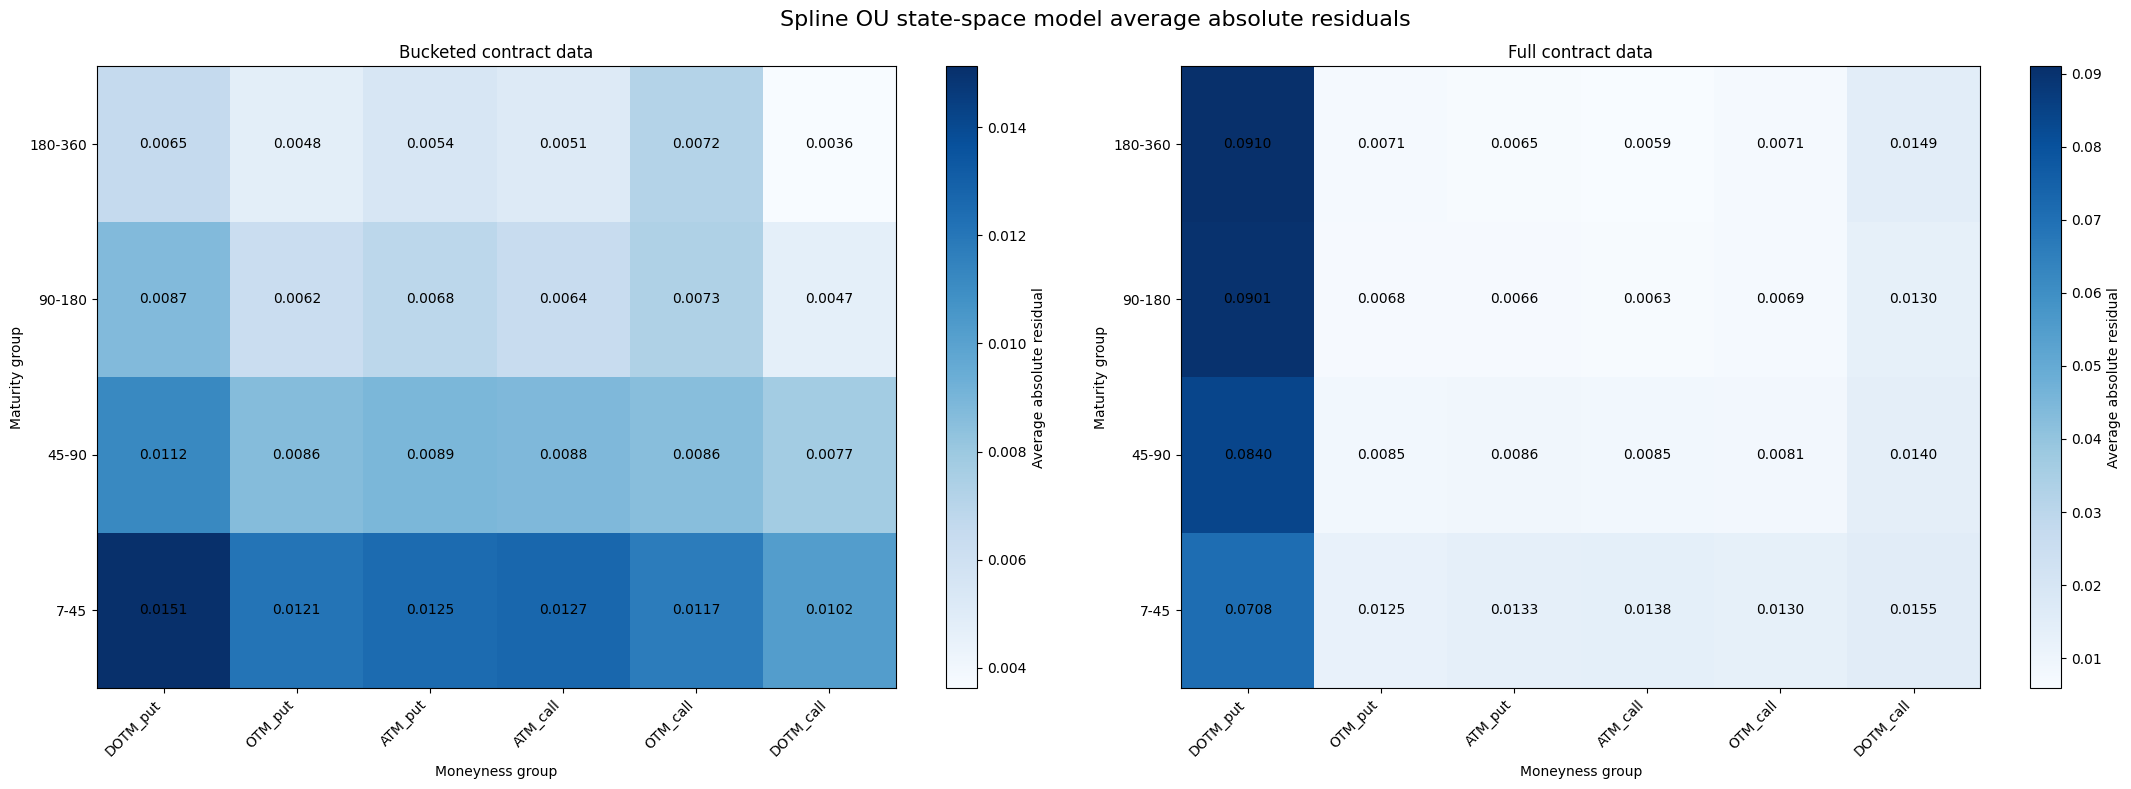

In [1152]:
# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Bucketed heatmap
data_heatmap_spline_bucketed, heatmap_table_spline_bucketed = make_state_model_residual_heatmap(
    x_test_spline,
    dates_test_spline,
    at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_spline)],
    prepare_groups_spline,
    title="Bucketed contract data",
    ax=axes[0],
    show=False)

# Full contract data heatmap
data_heatmap_spline_full, heatmap_table_spline_full = make_state_model_residual_heatmap(
    x_test_full_spline,
    dates_test_full_spline,
    at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline)],
    prepare_groups_spline,
    title="Full contract data",
    ax=axes[1],
    show=False)

# Set common title
fig.suptitle(
    "Spline OU state-space model average absolute residuals",
    fontsize=16)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.spline2.png", bbox_inches='tight')
plt.show()

# **2. STATISTICAL TESTS**

# **2.1 Diebold-Mariano test**

-------------------------------

The Diebold and Mariano (2002) test is used to compare the predictive accuracy of two competing forecasting
models. It does this by looking at the loss differential $dt = L(e_{1,t}) − L(e_{2,t})$, where $L(e_{1,t})$ and $L(e_{2,t})$ are
the forecast losses of model 1 and model 2, respectively. The null hypothesis is $H0 : \mathbb{E}[dt] = 0$, meaning the
two models have equal expected predictive accuracy. The alternative hypothesis is $HA : \mathbb{E}[dt] = 0$, meaning
the models differ in expected predictive accuracy. If $\mathbb{E}[dt] > 0$, model 2 performs better on average because
model 1 has higher loss, and vice versa. The test statistic reads:

$$DM = \frac{\bar d}{\sqrt{\hat S_d / T}}$$

Because forecast errors, and therefore loss differentials, can be serially correlated, the variance of $\bar d$ is estimated using a heteroskedasticity and autocorrelation consistent estimator, $\hat S_d = \hat \gamma_0 + 2 \sum^{h-1}_{j=1} \hat \gamma_j$.

- **Diebold-Mariano function**

In [1153]:
# Diebold-Mariano test function
def dm_test_loss(loss_model, loss_benchmark, lag=5):

    # Compute the loss differential
    loss_diff = np.asarray(loss_model) - np.asarray(loss_benchmark)

    # Length of the series, mean differential, and demean
    T = len(loss_diff)
    d_bar = np.mean(loss_diff)
    u = loss_diff - d_bar

    # Average squared deviation
    lrv = np.mean(u * u)

    # HAC standard errors
    for j in range(1, lag + 1):

        # Compute gamma and autocovariance corrections
        gamma = np.mean(u[j:] * u[:-j])
        lrv += 2 * (1 - j / (lag + 1)) * gamma

    # Compute standard error, test statistic, and p-value
    se = np.sqrt(lrv / T)
    dm_stat = d_bar / se
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    # Return the results
    return dm_stat, p_value

- **Compute losses**

In [1154]:
# Compute daily losses
def daily_loss(x, pred, loss="mse", group=None):

    # Copy the data and convert predictions to NumPy array
    df = x.copy()
    df["pred"] = np.asarray(pred)

    # Select only DOTM put if specified
    if group is not None:
        df = df[df["moneyness_group"] == group]

    # Sort the values
    df = df.sort_values(["quote_date", "moneyness_group", "maturity_group"])

    # Compute error
    err = df["iv_fun"] - df["pred"]

    # MSE or MAE based on function argument
    if loss == "mse":
        l = err**2
    elif loss == "mae":
        l = np.abs(err)

    # Group losses by take and take average loss for each date, then return result
    return l.groupby(pd.to_datetime(df["quote_date"]).to_numpy()).mean()


- **Create table for comparison**

In [1155]:
# DM table function
def dm_table(var_loss, models, loss="mse", group=None, lag=5):

    # Create empty list
    out = []

    # Loop over the dictionary as key-value pairs
    for name, (x, pred) in models.items():

        # Compute the model loss
        model_loss = daily_loss(x, pred, loss=loss, group=group)

        # Find dates that exist in both series for alignment
        common = model_loss.index.intersection(var_loss.index)

        # Compute the DM test statistic
        dm_stat, p_value = dm_test_loss(
            model_loss.loc[common].to_numpy(),
            var_loss.loc[common].to_numpy(),
            lag=lag)

        # Append the results to the list
        out.append([name, dm_stat, p_value])

    # Return the result as a DataFrame
    return pd.DataFrame(out, columns=["model", "DM statistic", "p-value"])

- **Bucketed results: all regions**

In [1156]:
# Specify models
models = {
    "Basic VAR": (x_test, iv_pred_basic),
    "OU state space": (x_test, iv_pred_test_ou),
    "Spline OU state space": (x_test_spline, iv_pred_test_spline)}

# Loop over the loss metrics
for loss in ["mse", "mae"]:

    # Compute the loss
    var_loss = daily_loss(x_test_var, iv_pred_test_var, loss=loss)

    # Extract COVID period
    covid = pd.to_datetime(var_loss.index).to_series(index=var_loss.index).between("2020-01-01", "2022-12-31")

    # Print the full sample results
    print(f"Full sample {loss.upper()}")
    display(dm_table(var_loss, models, loss=loss))

    # Print the non-COVID period results
    print(f"Non-COVID period {loss.upper()}")
    display(dm_table(var_loss.loc[~covid], models, loss=loss))

    # Print the COVID period results
    print(f"COVID period {loss.upper()}")
    display(dm_table(var_loss.loc[covid], models, loss=loss))

Full sample MSE


,model,DM statistic,p-value
0,Basic VAR,-3.587592,3.337456e-04
1,OU state space,2.010979,4.432771e-02
2,Spline OU state space,-6.038321,1.557265e-09


Non-COVID period MSE


,model,DM statistic,p-value
0,Basic VAR,-4.855268,1.202239e-06
1,OU state space,2.544998,1.092783e-02
2,Spline OU state space,-7.385804,1.514344e-13


COVID period MSE


...

,model,DM statistic,p-value
0,Basic VAR,-7.524502,5.284662e-14
1,OU state space,3.537401,4.040850e-04
2,Spline OU state space,-13.930106,0.000000e+00


Non-COVID period MAE


,model,DM statistic,p-value
0,Basic VAR,-5.033176,4.824187e-07
1,OU state space,2.181211,2.916782e-02
2,Spline OU state space,-9.469082,0.000000e+00


COVID period MAE


,model,DM statistic,p-value
0,Basic VAR,-6.239591,4.387157e-10
1,OU state space,3.117259,1.825414e-03
2,Spline OU state space,-11.251675,0.000000e+00


- **Bucketed results: DOTM put region**

In [1157]:
# Specify the group
group = "DOTM_put"

# Loop over the loss metrics
for loss in ["mse", "mae"]:

    # Compute the loss
    var_loss = daily_loss(x_test_var, iv_pred_test_var, loss=loss, group=group)

    # Extract COVID period
    covid = pd.to_datetime(var_loss.index).to_series(index=var_loss.index).between("2020-01-01", "2022-12-31")

    # Print the full sample results
    print(f"DOTM put Full sample {loss.upper()}")
    display(dm_table(var_loss, models, loss=loss, group=group))

    # Print the non-COVID period results
    print(f"DOTM put Non-COVID period {loss.upper()}")
    display(dm_table(var_loss.loc[~covid], models, loss=loss, group=group))

    # Print the COVID period results
    print(f"DOTM put COVID period {loss.upper()}")
    display(dm_table(var_loss.loc[covid], models, loss=loss, group=group))

DOTM put Full sample MSE


,model,DM statistic,p-value
0,Basic VAR,-2.768294,0.005635
1,OU state space,1.024330,0.305679
2,Spline OU state space,-0.021766,0.982635


DOTM put Non-COVID period MSE


,model,DM statistic,p-value
0,Basic VAR,-10.809216,0.000000e+00
1,OU state space,-5.215599,1.832241e-07
2,Spline OU state space,-2.892430,3.822747e-03


DOTM put COVID period MSE


...

,model,DM statistic,p-value
0,Basic VAR,-10.093226,0.000000e+00
1,OU state space,-9.024544,0.000000e+00
2,Spline OU state space,-5.788018,7.122189e-09


DOTM put Non-COVID period MAE


,model,DM statistic,p-value
0,Basic VAR,-7.163478,7.864820e-13
1,OU state space,-9.250350,0.000000e+00
2,Spline OU state space,-6.345567,2.216083e-10


DOTM put COVID period MAE


,model,DM statistic,p-value
0,Basic VAR,-8.882367,0.000000e+00
1,OU state space,-5.161850,2.445213e-07
2,Spline OU state space,-3.275868,1.053379e-03


- **Full contract results: all regions**

In [1158]:
# Specify the models
models_full = {
    "OU state space": (x_test_full_ou, iv_pred_test_full_ou),
    "Spline OU state space": (x_test_full_spline, iv_pred_test_full_spline)}

# Loop over the metrics
for loss in ["mse", "mae"]:

    # Compute losses
    var_loss = daily_loss(x_test_full_var, iv_pred_test_full_var, loss=loss)

    # Extract covid period and non-2023 period
    covid = pd.to_datetime(var_loss.index).to_series(index=var_loss.index).between("2020-01-01", "2022-12-31")
    non_2023 = pd.to_datetime(var_loss.index).to_series(index=var_loss.index).dt.year != 2023

    # Print full sample results
    print(f"Full sample {loss.upper()}")
    display(dm_table(var_loss, models_full, loss=loss))

    # Print COVID results
    print(f"COVID period {loss.upper()}")
    display(dm_table(var_loss.loc[covid], models_full, loss=loss))

    # Print excluding 2023 results
    print(f"Excluding 2023 {loss.upper()}")
    display(dm_table(var_loss.loc[non_2023], models_full, loss=loss))

Full sample MSE


,model,DM statistic,p-value
0,OU state space,-1.583364,0.113339
1,Spline OU state space,-1.601426,0.109283


COVID period MSE


,model,DM statistic,p-value
0,OU state space,0.799362,0.424081
1,Spline OU state space,-4.615060,0.000004


Excluding 2023 MSE


...

,model,DM statistic,p-value
0,OU state space,-1.296996,0.194633
1,Spline OU state space,-2.441659,0.014620


COVID period MAE


,model,DM statistic,p-value
0,OU state space,4.247708,0.000022
1,Spline OU state space,-4.464110,0.000008


Excluding 2023 MAE


,model,DM statistic,p-value
0,OU state space,4.758927,0.000002
1,Spline OU state space,-1.097155,0.272574


- **Full contract results: DOTM put region**

In [1159]:
# Loop over the loss metrics
for loss in ["mse", "mae"]:

    # Compute losses
    var_loss = daily_loss(x_test_full_var, iv_pred_test_full_var, loss=loss, group=group)

    # Extract COVID and non-2023 period
    covid = pd.to_datetime(var_loss.index).to_series(index=var_loss.index).between("2020-01-01", "2022-12-31")
    non_2023 = pd.to_datetime(var_loss.index).to_series(index=var_loss.index).dt.year != 2023

    # Print the full sample results
    print(f"DOTM put Full sample {loss.upper()}")
    display(dm_table(var_loss, models_full, loss=loss, group=group))

    # Print COVID results
    print(f"DOTM put COVID period {loss.upper()}")
    display(dm_table(var_loss.loc[covid], models_full, loss=loss, group=group))

    # Print non-2023 results
    print(f"DOTM put Excluding 2023 {loss.upper()}")
    display(dm_table(var_loss.loc[non_2023], models_full, loss=loss, group=group))

DOTM put Full sample MSE


,model,DM statistic,p-value
0,OU state space,-1.606426,0.108180
1,Spline OU state space,-1.624443,0.104281


DOTM put COVID period MSE


,model,DM statistic,p-value
0,OU state space,0.708659,0.478536
1,Spline OU state space,-4.117841,0.000038


DOTM put Excluding 2023 MSE


...

,model,DM statistic,p-value
0,OU state space,-1.346136,0.178259
1,Spline OU state space,-0.510764,0.609516


DOTM put COVID period MAE


,model,DM statistic,p-value
0,OU state space,3.736620,0.000187
1,Spline OU state space,-1.020869,0.307316


DOTM put Excluding 2023 MAE


,model,DM statistic,p-value
0,OU state space,4.205630,0.000026
1,Spline OU state space,1.653644,0.098200


- **Bucketed data pairwise DM heatmaps**

In [1160]:
# Pairwise Diebold-Mariano test function
def pairwise_dm_matrices(losses):

    # Extract the model names from the dictionary and store them as a list
    names = list(losses.keys())

    # Create two empty square DataFrames
    dm_mat = pd.DataFrame(index=names, columns=names, dtype=float)
    p_mat = pd.DataFrame(index=names, columns=names, dtype=float)

    # Loop to fill the pairwise DM matrix
    for i in names:
        for j in names:

            # If row and column model are the same, do not run DM test
            if i == j:
                dm_mat.loc[i, j] = np.nan
                p_mat.loc[i, j] = np.nan

            # Else extract the DM results
            else:

                # Obtain common dates
                common = losses[i].index.intersection(losses[j].index)

                # Apply DM test
                dm_stat, p_value = dm_test_loss(
                    losses[i].loc[common].to_numpy(),
                    losses[j].loc[common].to_numpy())

                # Store the DM statistic and p-value
                dm_mat.loc[i, j] = dm_stat
                p_mat.loc[i, j] = p_value

    # Return the results
    return dm_mat, p_mat, names

In [1161]:
# Significance stars helper function
def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

In [1162]:
# Heatmap drawing function
def add_dm_heatmap(ax, dm_mat, p_mat, names, title, cmap):

    # Find the largest absolute DM statistic in the matrix, ignore the NaN
    v = np.nanmax(np.abs(dm_mat.to_numpy(dtype=float)))
    color_norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)

    # Draw the heatmap
    im = ax.imshow(dm_mat.astype(float), cmap=cmap, norm=color_norm)

    # Set x- and y-axis specifics
    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)

    # Write text inside each heatmap cell
    for r in range(len(names)):
        for c in range(len(names)):

            # Check whether cell is missing (diagonal), write a - there
            if pd.isna(dm_mat.iloc[r, c]):
                ax.text(c, r, "-", ha="center", va="center", fontsize=8)
            else:
                # Get the p-value and convert it into stars
                p = p_mat.iloc[r, c]
                stars = significance_stars(p)

                # Write the DM statistic and p-value inside the cell
                ax.text(
                    c, r,
                    f"{dm_mat.iloc[r, c]:.2f}{stars}\n({p:.3f})",
                    ha="center",
                    va="center",
                    fontsize=8)

    # Set the title
    ax.set_title(title)

    # Return the result
    return im

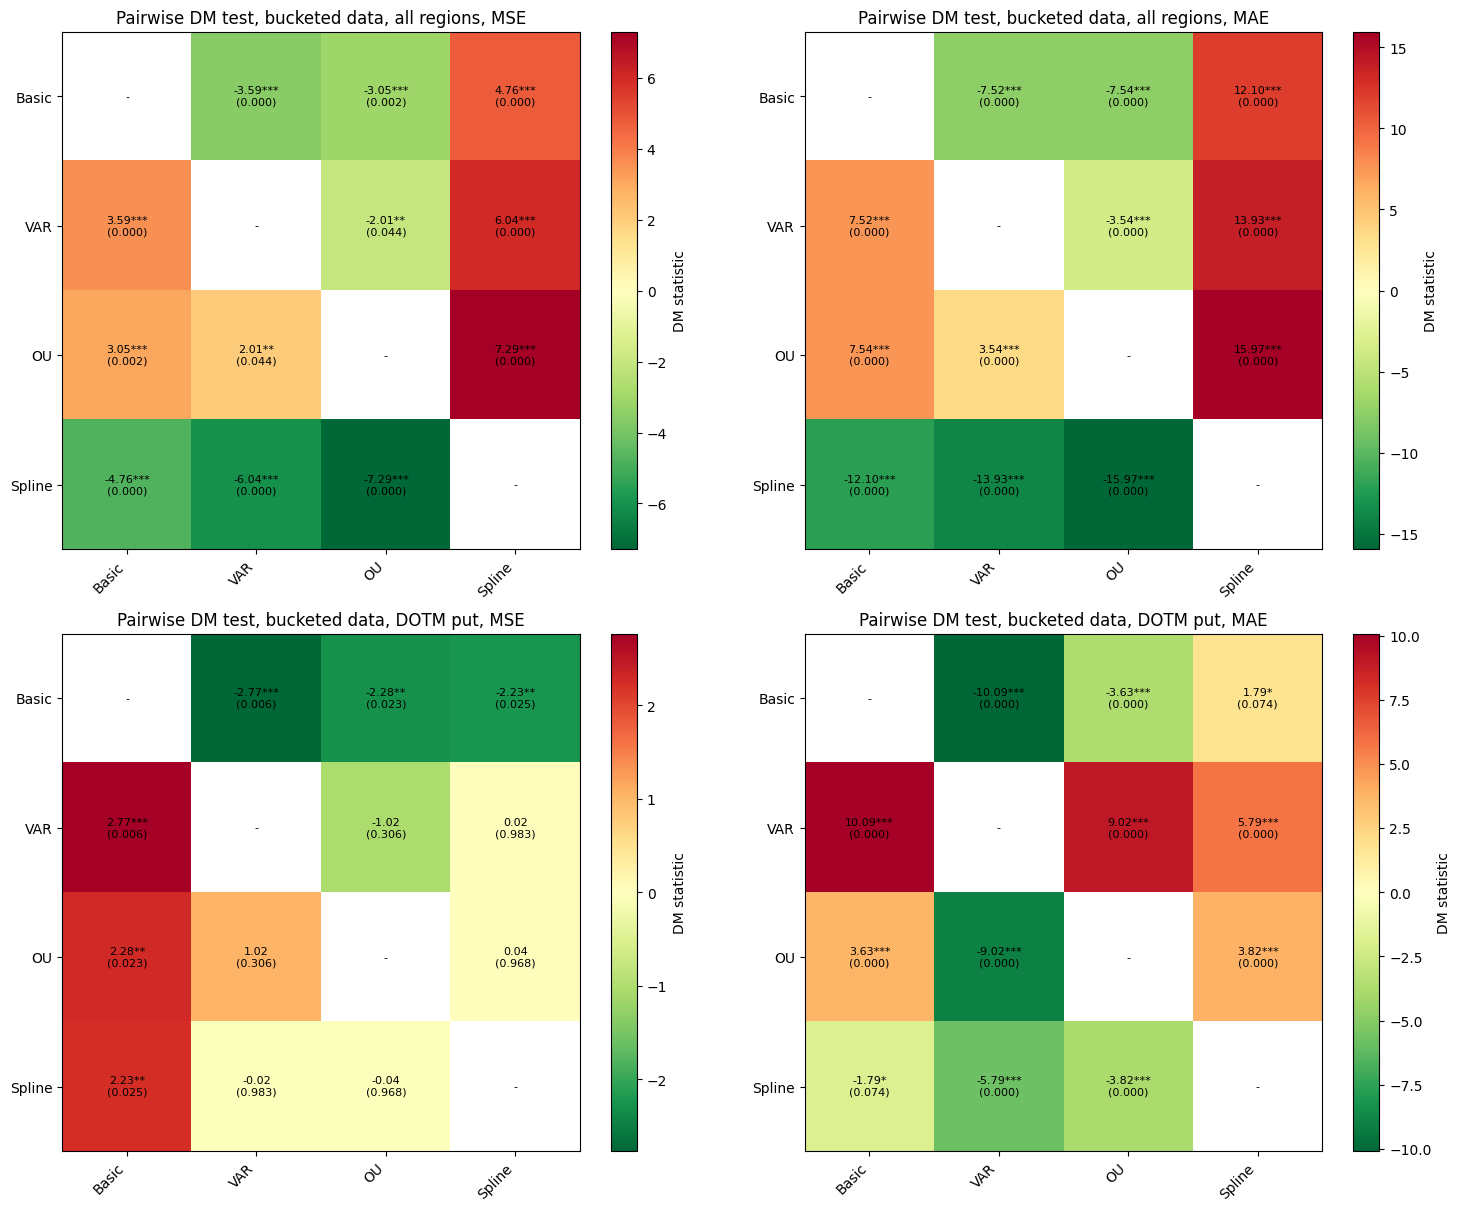

In [1163]:
# Specify bucketed losses
losses_bucketed_mse = {
    "Basic": daily_loss(x_test, iv_pred_basic, loss="mse"),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, loss="mse"),
    "OU": daily_loss(x_test, iv_pred_test_ou, loss="mse"),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, loss="mse")
}

losses_bucketed_mae = {
    "Basic": daily_loss(x_test, iv_pred_basic, loss="mae"),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, loss="mae"),
    "OU": daily_loss(x_test, iv_pred_test_ou, loss="mae"),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, loss="mae")
}

# Call the function twice, for MSE and MAE
dm_mse, p_mse, names = pairwise_dm_matrices(losses_bucketed_mse)
dm_mae, p_mae, _ = pairwise_dm_matrices(losses_bucketed_mae)

# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Draw the heatmap for MSE and store result
im_mse = add_dm_heatmap(
    axes[0],
    dm_mse,
    p_mse,
    names,
    "Pairwise DM test, bucketed data, MSE",
    cmap)

# Draw the heatmap for MAE and store result
im_mae = add_dm_heatmap(
    axes[1],
    dm_mae,
    p_mae,
    names,
    "Pairwise DM test, bucketed data, MAE",
    cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.bucketed.png", bbox_inches='tight')
plt.show()

- **Full contract data pairwise DM heatmaps**

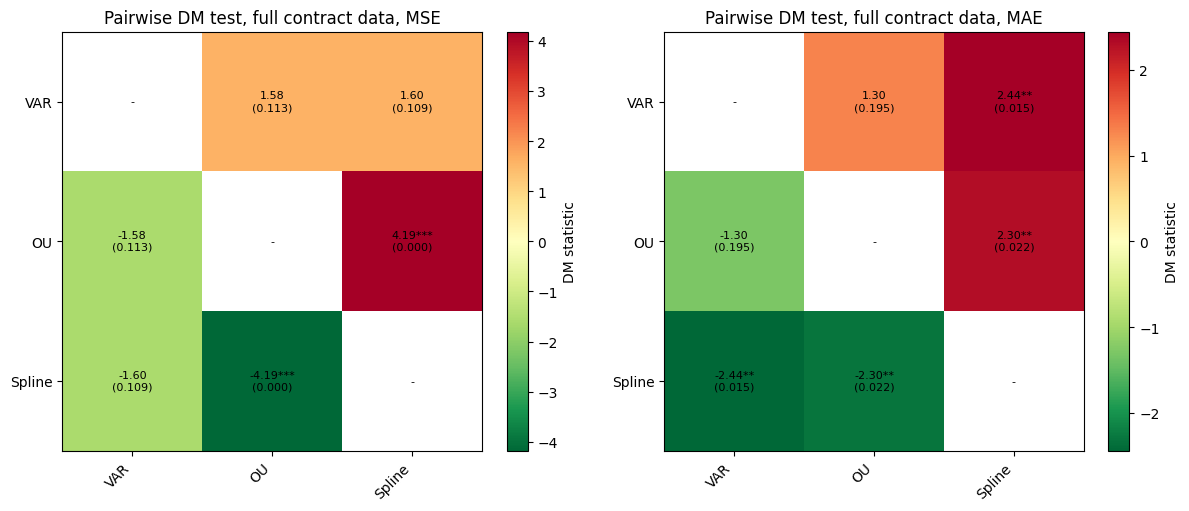

In [1164]:
# Full contract non-bucketed losses
losses_full_mse = {
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, loss="mse"),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, loss="mse"),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, loss="mse")}

losses_full_mae = {
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, loss="mae"),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, loss="mae"),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, loss="mae")}

# Call pairwise DM function
dm_mse_full, p_mse_full, names_full = pairwise_dm_matrices(losses_full_mse)
dm_mae_full, p_mae_full, _ = pairwise_dm_matrices(losses_full_mae)

# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Draw the heatmap for MSE and store result
im_mse = add_dm_heatmap(
    axes[0],
    dm_mse_full,
    p_mse_full,
    names_full,
    "Pairwise DM test, full contract data, MSE",
    cmap)

# Draw the heatmap for MAE and store result
im_mae = add_dm_heatmap(
    axes[1],
    dm_mae_full,
    p_mae_full,
    names_full,
    "Pairwise DM test, full contract data, MAE",
    cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.non.bucketed.png", bbox_inches="tight")
plt.show()

# **2.2 Model Confidence Set**

---------------------

\noindent The Model Confidence Set procedure of Hansen et al. (2011)} provides a formal method for eliminating inferior models without asymptotic size inflation, yielding a final set of models with Equal Predictive Ability at a chosen confidence level. Starting from a pool $\mathcal{M}$ of candidate models with losses $L_{m, T+s}$, pairwise loss differentials $d_{m,m',T+s}$ are computed for models $m$ and $m'$ at time $T+s$. The objective is to identify the subset $\mathcal{M}^*_{1-\alpha}$ of models that cannot be statistically distinguished in terms of predictive performance. The null hypothesis is $H_0: \mathbb{E}[d_{m,m',T+s}] = 0, \forall m,m' \in \mathcal{M}^*_{1-\alpha}$. If $H_0$ is rejected, the worst-performing model is removed according to an elimination rule, and the procedure is continued until $H_0$ is accepted. The remaining set $\mathcal{M}^*_{1-\alpha}$ is the Model Confidence Set. The test statistic reads:

$$T_{R, \mathcal{M}} = \max_{m, m' \in \mathcal{M}}|t_{m, m'}|$$

 If the EPA test is rejected, the worst performing model is removed from the set, and the test is repeated on the reduced model set. This elimination procedure continues until the EPA null is no longer rejected. The remaining models then form the MCS $\mathcal{M}_{1-\alpha}^*$ which contains the models that are statistically indistinguishable in terms of predictive ability at confidence level $1-\alpha$.

- **Align series**

In [1165]:
# Align losses
def align_losses(losses):

    # Initialize common
    common = None

    # Loop over series
    for loss_series in losses.values():

        # Use the first model's dates as the starting set of dates
        if common is None:
            common = loss_series.index

        # Keep only the dates that are already in common
        else:
            common = common.intersection(loss_series.index)

    # Sort values
    common = common.sort_values()

    # Store results in DF
    loss_df = pd.DataFrame({
        name: loss_series.loc[common].to_numpy()
        for name, loss_series in losses.items()
    }, index=common)

    # Return the results
    return loss_df

- **HAC helper function**

In [1166]:
# HAC standard error function
def hac_se(d, lag=5):

    # Convert to NumPy array
    d = np.asarray(d)

    # Length pf array, mean differential, and demean
    T = len(d)
    d_bar = np.mean(d)
    u = d - d_bar

    # Take mean of outer product
    lrv = np.mean(u * u)

    # HAC standard errors
    for j in range(1, lag + 1):
        gamma = np.mean(u[j:] * u[:-j])
        lrv += 2 * (1 - j / (lag + 1)) * gamma

    # Return the results
    return np.sqrt(lrv / T)

- **Block bootstrap**

In [1167]:
# Block bootstrap function
def block_bootstrap_indices(T, block_size, B):

    # Create empty list
    all_indices = []

    # Repeat the procedure B times
    for _ in range(B):

        # Create empty list
        idx = []

        # Keep adding blocks until bootstrap sample has T indices
        while len(idx) < T:

            # Randomly choose where the block starts
            start = np.random.randint(0, T - block_size + 1)

            # Add a consecutive block of indices
            idx.extend(range(start, start + block_size))

        # Cut so it has exactly length T
        all_indices.append(np.array(idx[:T]))

    # Return the results
    return all_indices

- **MCS function**

In [1168]:
# MCS function
def mcs_test(loss_df, alpha=0.10, B=1000, block_size=5, lag=5):

    # Create list of models still in MCS procedure

    # Create empty list to store models that are removed
    active = list(loss_df.columns)
    eliminated = []

    # Length of series
    T = len(loss_df)

    # Loop until only one model is left or null no longer rejected
    while len(active) > 1:

        # Keep only current active models
        L = loss_df[active]

        # Create empty matric for pairwise test statistics
        t_mat = pd.DataFrame(index=active, columns=active, dtype=float)

        # Loop over every pair of active models
        for i in active:
            for j in active:
                if i == j:
                    # Set the diagonal to be missing
                    t_mat.loc[i, j] = np.nan
                else:
                    # Compute loss differential between model i and j, the mean loss differential, and the HAC SE
                    d = L[i] - L[j]
                    d_mean = d.mean()
                    d_se = hac_se(d, lag=lag)

                    # Store the pairwise t-statistic
                    t_mat.loc[i, j] = d_mean / d_se

        # Compute MCS test statistic
        test_stat = np.nanmax(np.abs(t_mat.to_numpy(dtype=float)))

        # Generate bootstrap time indices using block bootstrap
        boot_indices = block_bootstrap_indices(T, block_size, B)
        boot_stats = []

        # Loop over each bootstrap sample
        for idx in boot_indices:

            # Create bootstrap version of loss matrix
            L_boot = L.iloc[idx].reset_index(drop=True)

            # Create empty pairwise bootstrap t-statistic matrix
            boot_t_mat = pd.DataFrame(index=active, columns=active, dtype=float)

            # Loop over every pair of active models
            for i in active:
                for j in active:
                    if i == j:
                        # Set diagonal to NaN
                        boot_t_mat.loc[i, j] = np.nan
                    else:
                        # Compute original loss differential
                        d = L[i].reset_index(drop=True) - L[j].reset_index(drop=True)
                        d_boot = L_boot[i] - L_boot[j]

                        # Center teh bootstrap loss differential around null of EPA
                        d_centered = d_boot.mean() - d.mean()

                        # use HAC SE's
                        d_se = hac_se(d, lag=lag)

                        # Store the bootstrap t-statistic
                        boot_t_mat.loc[i, j] = d_centered / d_se

            # Store the bootstrap max statistic
            boot_stats.append(np.nanmax(np.abs(boot_t_mat.to_numpy(dtype=float))))

        # COmpute bootstrap p-value
        p_value = np.mean(np.array(boot_stats) > test_stat)

        # If p-value larger than significance level, null is not rejected, procedure stops
        if p_value > alpha:
            break

        # Compute average loss for each currently active model
        avg_losses = L.mean()

        # Find model with highest average loss
        worst_model = avg_losses.idxmax()

        # Store the elimination step
        eliminated.append({
            "removed_model": worst_model,
            "average_loss": avg_losses[worst_model],
            "test_statistic": test_stat,
            "p_value": p_value})

        # Remove the worst model
        active.remove(worst_model)

    # Return the results
    return {
        "MCS": active,
        "eliminated": pd.DataFrame(eliminated)}

- **Bucketed data MCS results**

In [1169]:
# Align the losses by indexes
loss_df_mse = align_losses(losses_bucketed_mse)
loss_df_mae = align_losses(losses_bucketed_mae)

# Period indicators
covid = pd.to_datetime(loss_df_mse.index).to_series(index=loss_df_mse.index).between("2020-01-01", "2022-12-31")

# Create dictionary of period indicators
periods = {
    "Full sample": np.repeat(True, len(loss_df_mse)),
    "Non-COVID period": ~covid,
    "COVID period": covid}

# Run MCS for all periods
for period_name, period_idx in periods.items():

    # Print the MSE results
    print(f"MCS bucketed {period_name} MSE")
    mcs_mse = mcs_test(loss_df_mse.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mse["MCS"])
    display(mcs_mse["eliminated"])

    # Print the MAE results
    print(f"MCS bucketed {period_name} MAE")
    mcs_mae = mcs_test(loss_df_mae.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mae["MCS"])
    display(mcs_mae["eliminated"])

MCS bucketed Full sample MSE
['Spline']


,removed_model,average_loss,test_statistic,p_value
0,OU,0.000247,7.293768,0.0
1,VAR,0.000240,6.038321,0.0
2,Basic,0.000216,4.761925,0.0


MCS bucketed Full sample MAE
['Spline']


,removed_model,average_loss,test_statistic,p_value
0,OU,0.010686,15.968845,0.0
1,VAR,0.010558,13.930106,0.0
2,Basic,0.010116,12.095536,0.0


MCS bucketed Non-COVID period MSE
['Spline']


...

,removed_model,average_loss,test_statistic,p_value
0,OU,0.007633,10.932693,0.0
1,VAR,0.007554,9.469082,0.0
2,Basic,0.007243,8.578458,0.0


MCS bucketed COVID period MSE
['Spline']


,removed_model,average_loss,test_statistic,p_value
0,OU,0.000328,6.429862,0.0
1,VAR,0.000319,5.048743,0.0
2,Basic,0.000287,3.798757,0.0


MCS bucketed COVID period MAE
['Spline']


,removed_model,average_loss,test_statistic,p_value
0,OU,0.012431,13.012803,0.0
1,VAR,0.012275,11.251675,0.0
2,Basic,0.011759,9.585710,0.0


- **Full contract data MCS results**

In [1176]:
# Align losses
loss_df_full_mse = align_losses(losses_full_mse)
loss_df_full_mae = align_losses(losses_full_mae)

# Period indicators
covid = pd.to_datetime(loss_df_full_mse.index).to_series(index=loss_df_full_mse.index).between("2020-01-01", "2022-12-31")
non_2023 = pd.to_datetime(loss_df_full_mse.index).to_series(index=loss_df_full_mse.index).dt.year != 2023

# Dictionary of periods
periods = {
    "Full sample": np.repeat(True, len(loss_df_full_mse)),
    "COVID period": covid,
    "Excluding 2023": non_2023}

# Run MCS for all periods
for period_name, period_idx in periods.items():

    # Print MSE results
    print(f"MCS full contract {period_name} MSE")
    mcs_mse = mcs_test(loss_df_full_mse.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mse["MCS"])
    display(mcs_mse["eliminated"])

    print(f"MCS full contract {period_name} MAE")
    mcs_mae = mcs_test(loss_df_full_mae.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mae["MCS"])
    display(mcs_mae["eliminated"])

MCS full contract Full sample MSE
['Spline']


,removed_model,average_loss,test_statistic,p_value
0,VAR,0.280793,4.191867,0.0
1,OU,0.009923,4.191867,0.0


MCS full contract Full sample MAE
['Spline']


,removed_model,average_loss,test_statistic,p_value
0,VAR,0.041730,2.441659,0.022
1,OU,0.038362,2.297014,0.012


MCS full contract COVID period MSE
['Spline']


...

,removed_model,average_loss,test_statistic,p_value
0,OU,0.045743,6.483525,0.0
1,VAR,0.041979,4.464110,0.0


MCS full contract Excluding 2023 MSE
['Spline']


,removed_model,average_loss,test_statistic,p_value
0,OU,0.011090,4.628287,0.001
1,VAR,0.010317,2.958492,0.003


MCS full contract Excluding 2023 MAE
['VAR', 'Spline']


,removed_model,average_loss,test_statistic,p_value
0,OU,0.041536,4.592967,0.0


In [1171]:


spline_predictions = {
    "iv_pred_train_spline": iv_pred_train_spline,
    "iv_pred_test_spline": iv_pred_test_spline
}

with open("iv_pred_spline.pkl", "wb") as f:
    pickle.dump(spline_predictions, f)